# NLP and Deep Learning for Text Classification in Medical Diagnosis

## Research Question

RQ1: What is the effectiveness of the NLP algorithm in classifying patient symptoms from the text data on the population level?
- **H10**: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support.
- **H1a**: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support.

## Overview

This notebook implements a complete text classification pipeline to analyze medical symptom descriptions and classify them into appropriate diagnostic categories. We'll evaluate multiple NLP approaches and deep learning models to determine which provides the best performance for medical symptom classification.

## 1. Environment Setup

Import all necessary libraries for our analysis. This includes data manipulation, visualization, NLP, machine learning and deep learning tools.

In [57]:
# Import required libraries
import pandas as pd  # For data manipulation and analysis with DataFrames
import numpy as np  # For numerical operations and array handling
import matplotlib.pyplot as plt  # For creating static plots and visualizations
import seaborn as sns  # For statistical data visualization with attractive styling
import plotly.express as px  # For interactive plotting with simple syntax
import plotly.graph_objects as go  # For advanced interactive plotting with detailed control
from plotly.subplots import make_subplots  # For creating subplot layouts in plotly
import re  # For regular expression operations (text pattern matching)
import string  # For string constants and operations
import os  # For operating system interface (file/directory operations)
import warnings  # For controlling warning messages during execution
from wordcloud import WordCloud  # For generating word cloud visualizations
from PIL import Image  # For image processing and manipulation

# NLP libraries
import nltk  # Natural Language Toolkit for text processing
from nltk.corpus import stopwords  # Pre-defined list of common words to filter out
from nltk.tokenize import word_tokenize  # For splitting text into individual words/tokens
from nltk.stem import WordNetLemmatizer, PorterStemmer  # For reducing words to root forms
from textblob import TextBlob  # For sentiment analysis and text processing
import textstat  # For calculating text readability and complexity metrics

# Machine learning libraries
import sklearn  # Comprehensive machine learning library
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score  # For data splitting and model evaluation
from sklearn.preprocessing import LabelEncoder  # For converting categorical labels to numerical format
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer  # For converting text to numerical features
from sklearn.naive_bayes import MultinomialNB  # Naive Bayes classifier for text classification
from sklearn.linear_model import LogisticRegression  # Linear model for classification tasks
from sklearn.svm import LinearSVC  # Support Vector Machine for classification
from sklearn.ensemble import RandomForestClassifier  # Ensemble method using multiple decision trees
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support  # For model performance evaluation
from sklearn.pipeline import Pipeline  # For chaining preprocessing and model steps
from imblearn.over_sampling import SMOTE  # For handling imbalanced datasets by generating synthetic samples

# Deep learning libraries
import tensorflow as tf  # Google's deep learning framework
from tensorflow.keras.models import Sequential  # For building neural networks layer by layer
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalMaxPooling1D, Conv1D, MaxPooling1D  # Various neural network layer types
from tensorflow.keras.preprocessing.text import Tokenizer  # For converting text to sequences of numbers
from tensorflow.keras.preprocessing.sequence import pad_sequences  # For making all text sequences the same length
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # For controlling training process and saving best models
from tensorflow.keras.utils import to_categorical  # For one-hot encoding categorical variables

# Suppress warnings
warnings.filterwarnings('ignore')  # Hide warning messages to keep output clean

# Download NLTK resources
try:
    nltk.data.find('tokenizers/punkt')  # Check if punkt tokenizer is already downloaded
    nltk.data.find('corpora/stopwords')  # Check if stopwords corpus is already downloaded
    nltk.data.find('corpora/wordnet')  # Check if wordnet corpus is already downloaded
except LookupError:
    nltk.download('punkt')  # Download sentence tokenizer if not found
    nltk.download('stopwords')  # Download list of common words if not found
    nltk.download('wordnet')  # Download word database for lemmatization if not found

# Set random seeds for reproducibility
np.random.seed(42)  # Ensure numpy random operations produce consistent results
tf.random.set_seed(42)  # Ensure tensorflow random operations produce consistent results

# Configure visualization settings
plt.style.use('fivethirtyeight')  # Apply FiveThirtyEight website's plotting style
sns.set(style='whitegrid')  # Set seaborn to use white background with grid lines

# Display versions of key libraries
print(f"Pandas version: {pd.__version__}")  # Show pandas version for compatibility checking
print(f"NumPy version: {np.__version__}")  # Show numpy version for compatibility checking
print(f"TensorFlow version: {tf.__version__}")  # Show tensorflow version for compatibility checking
print(f"Scikit-learn version: {sklearn.__version__}")  # Show scikit-learn version for compatibility checking

Pandas version: 2.0.2
NumPy version: 1.23.5
TensorFlow version: 2.12.0
Scikit-learn version: 1.0.2


[nltk_data] Downloading package punkt to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 2. Data Loading and Exploration

**Purpose:** Load the dataset and explore its structure. Focus on the key fields for our analysis: 'phrase' (patient descriptions) and 'prompt' (diagnostic categories).

In [58]:
# Define the dataset path - specify the complete file path to the CSV file containing medical speech data
data_path = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent\overview-of-recordings.csv'

# Load the dataset - read the CSV file into a pandas DataFrame for data manipulation and analysis
df = pd.read_csv(data_path)

# Define key fields for analysis as specified - these are the two main columns we'll focus on for text classification
key_fields = ['phrase', 'prompt']  # 'phrase' contains patient symptom descriptions, 'prompt' contains diagnostic categories

# Display basic information about the dataset - show the structure and size of our loaded data
print(f"Dataset shape: {df.shape}")  # Shows (number of rows, number of columns)
print(f"\nDataset columns: {df.columns.tolist()}")  # Lists all available column names in the dataset
print(f"\nKey fields for analysis: {key_fields}")  # Confirms which columns we'll use for our NLP analysis

# Display the first few rows of the dataset focused on our key fields - preview the actual data we'll be working with
print("\nSample data (first 5 rows):")
df[key_fields].head()  # Shows first 5 rows of only the 'phrase' and 'prompt' columns to understand data structure

Dataset shape: (6661, 13)

Dataset columns: ['audio_clipping', 'audio_clipping:confidence', 'background_noise_audible', 'background_noise_audible:confidence', 'overall_quality_of_the_audio', 'quiet_speaker', 'quiet_speaker:confidence', 'speaker_id', 'file_download', 'file_name', 'phrase', 'prompt', 'writer_id']

Key fields for analysis: ['phrase', 'prompt']

Sample data (first 5 rows):


,phrase,prompt
0,When I remember her I feel down,Emotional pain
1,When I carry heavy things I feel like breaking...,Hair falling out
2,there is too much pain when i move my arm,Heart hurts
3,My son had his lip pierced and it is swollen a...,Infected wound
4,My muscles in my lower back are aching,Infected wound


### 2.1 Data Cleaning (Data Quality Check)

**Purpose:** Check for missing values, duplicates, and other data quality issues in our key fields.

In [59]:
# Check for missing values in key fields
print("Missing values in key fields:")
print(df[key_fields].isna().sum())  # Count null/NaN values in 'phrase' and 'prompt' columns to identify data quality issues

# Check for duplicates in phrases
duplicates = df.duplicated(subset=['phrase']).sum()  # Count how many patient symptom descriptions appear more than once in the dataset
print(f"\nDuplicate phrases: {duplicates}")

# Check class distribution (diagnostic categories)
print("\nClass distribution (top 10 diagnostic categories):")
class_distribution = df['prompt'].value_counts()  # Count frequency of each diagnostic category to understand dataset balance
print(class_distribution.head(10))

# Calculate class imbalance statistics
total_classes = len(class_distribution)  # Get total number of unique diagnostic categories in the dataset
print(f"\nTotal number of unique diagnostic categories: {total_classes}")

# Check statistics on text length
df['phrase_length'] = df['phrase'].str.len()  # Calculate character length of each patient symptom description for preprocessing insights
print("\nText length statistics:")
print(df['phrase_length'].describe())  # Display statistical summary (mean, std, min, max) of text lengths

# Remove temporary column
df.drop('phrase_length', axis=1, inplace=True)  # Clean up by removing the temporary length column to keep dataset tidy

Missing values in key fields:
phrase    0
prompt    0
dtype: int64

Duplicate phrases: 5955

Class distribution (top 10 diagnostic categories):
prompt
Acne              328
Shoulder pain     320
Joint pain        318
Infected wound    306
Knee pain         305
Cough             293
Feeling dizzy     283
Muscle pain       282
Heart hurts       273
Ear ache          270
Name: count, dtype: int64

Total number of unique diagnostic categories: 25

Text length statistics:
count    6661.000000
mean       50.026122
std        23.672184
min         9.000000
25%        33.000000
50%        45.000000
75%        61.000000
max       155.000000
Name: phrase_length, dtype: float64


### 2.2 Data Visualization

**Purpose:** Visualize the class distribution and text characteristics to gain a better understanding of our dataset.

In [60]:
# Visualize class distribution (top 15 categories)
top_n = 15  # Set the number of top diagnostic categories to display in our visualization
top_categories = class_distribution.head(top_n).reset_index()  # Extract the 15 most frequent diagnostic categories and reset index to create a clean dataframe
top_categories.columns = ['Category', 'Count']  # Rename columns to more descriptive names for clarity in visualization

# Create an interactive bar chart showing the distribution of diagnostic categories
fig = px.bar(top_categories, x='Category', y='Count', 
             title=f'Distribution of Top {top_n} Diagnostic Categories',  # Dynamic title that shows exactly how many categories we're displaying
             color='Count', color_continuous_scale='viridis')  # Color bars based on count values using a professional color scheme
fig.update_layout(xaxis={'categoryorder':'total descending'})  # Ensure categories are ordered from highest to lowest count for better readability
fig.show()  # Display the interactive chart

# Calculate text length metrics for preprocessing insights
df['text_length'] = df['phrase'].apply(len)  # Count the number of characters in each patient symptom description
df['word_count'] = df['phrase'].apply(lambda x: len(str(x).split()))  # Count the number of words in each patient symptom description by splitting on spaces

# Visualize text length distribution using subplots for comprehensive analysis
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Distribution of Text Length (Characters)', 
                                  'Distribution of Word Count'))  # Create side-by-side histograms with descriptive titles

# Add histogram for character length distribution
fig.add_trace(
    go.Histogram(x=df['text_length'], nbinsx=30, marker_color='blue'),  # Create histogram with 30 bins to show character length distribution patterns
    row=1, col=1  # Place in the first subplot position
)

# Add histogram for word count distribution
fig.add_trace(
    go.Histogram(x=df['word_count'], nbinsx=30, marker_color='green'),  # Create histogram with 30 bins to show word count distribution patterns
    row=1, col=2  # Place in the second subplot position
)

fig.update_layout(height=500, width=1000, title_text="Text Length Analysis")  # Set figure dimensions and overall title for the analysis
fig.show()  # Display the comprehensive text length analysis

# Remove temporary columns to keep dataset clean
df.drop(['text_length', 'word_count'], axis=1, inplace=True)  # Delete the temporary analysis columns since we only needed them for visualization, not for model training

## 3. Text Data Preprocessing

**Purpose:** Transforming the cleaned text data into a format suitable for machine learning algorithms.

### 3.1 Define Basic Text Cleaning Function

**Purpose:** To clean the raw text data by converting it to lowercase, replacing contractions, removing special characters, and extra whitespaces.

In [61]:
def clean_text(text):
    """Basic text cleaning function"""
    if isinstance(text, str):  # Check if text is a string
        # Convert to lowercase for standardization - ensures consistent text processing regardless of original case
        text = text.lower()
        
        # Replace contractions with full words - expands common English contractions to improve text analysis accuracy
        text = re.sub(r"what's", "what is", text)
        text = re.sub(r"'s", " is", text)
        text = re.sub(r"'ve", " have", text)
        text = re.sub(r"can't", "cannot", text)
        text = re.sub(r"n't", " not", text)
        text = re.sub(r"'re", " are", text)
        text = re.sub(r"'d", " would", text)
        text = re.sub(r"'ll", " will", text)
        text = re.sub(r"'t", " not", text)
        
        # Remove special characters and digits - keeps only alphabetic characters and spaces for cleaner text analysis
        text = re.sub(r"[^a-zA-Z\s]", "", text)
        
        # Remove extra whitespaces - consolidates multiple spaces into single spaces and removes leading/trailing whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    else:
        return ""  # Return empty string if input is not a string type to prevent processing errors

### 3.2 Initialize NLTK Components

**Purpose:** Set up the necessary tools for advanced preprocessing, such as stopword lists and lemmatizers.

In [62]:
# Initialize NLTK components for advanced text preprocessing
stop_words = set(stopwords.words('english'))  # Load standard English stopwords (common words like 'the', 'and', 'is' that don't carry much meaning)
medical_stopwords_to_keep = {'pain', 'ache', 'fever', 'swelling', 'rash'}  # Define medical terms that are important for symptom analysis and should NOT be removed
filtered_stop_words = stop_words - medical_stopwords_to_keep  # Create final stopwords list by removing medical terms from standard stopwords to preserve critical symptom information
lemmatizer = WordNetLemmatizer()  # Initialize lemmatizer to reduce words to their root form (e.g., 'running' -> 'run', 'better' -> 'good')

### 3.3 Define Advanced Preprocessing Function

**Purpose:** Combine basic cleaning with tokenization, stopword removal, and lemmatization for more refined text processing.

1. **Tokenization:** This involves breaking down a sentence or paragraph into smaller units, which can be words, punctuation marks, or other meaningful units.

2. **Stopword Removal:** This step removes common words that don't add much meaning to the text and can be noise for analysis. Examples include "the," "a," "an," "is," and "are."

3. **Lemmatization:** This reduces words to their root form, ensuring that "feeling," "felt," and "feels" are all reduced to "run." It also considers the word's context and part of speech, making it more accurate than stemming.

In [63]:
def advanced_preprocess(text):
    """Advanced preprocessing with tokenization, stopword removal, and lemmatization"""
    # Check if input is valid string with content - return empty string if not to prevent errors
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    # Apply basic text cleaning first (lowercase, remove punctuation, fix contractions)
    text = clean_text(text)
    
    # Split text into individual words/tokens for processing each word separately
    tokens = word_tokenize(text)
    
    # Remove common words (stopwords) that don't add meaning and reduce each word to its root form (lemmatization)
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in filtered_stop_words]
    
    # Combine the processed tokens back into a single cleaned text string
    processed_text = ' '.join(tokens)
    
    return processed_text

### 3.4 Process the Text Data

**Purpose:** Apply the cleaning and advanced preprocessing functions to the specified column of the DataFrame and create new columns for cleaned and processed text.

In [64]:
# Process the text data
print("Preprocessing text data...")
df['clean_phrase'] = df['phrase'].apply(clean_text)  # Apply basic text cleaning (lowercase, remove punctuation, expand contractions) to create standardized text for analysis
df['processed_phrase'] = df['phrase'].apply(advanced_preprocess)  # Apply advanced NLP preprocessing (tokenization, stopword removal, lemmatization) to prepare text for machine learning models

Preprocessing text data...


### 3.5 Display Sample Results

**Purpose:** Show a random sample of original, cleaned, and processed text to verify the effectiveness of the preprocessing steps.

In [65]:
# Display samples of original and processed text
print("\nSample text preprocessing results:")
sample_idx = np.random.randint(0, len(df), 5)  # Generate 5 random indices from the dataset to show diverse examples of text preprocessing
for idx in sample_idx:
    print(f"\nOriginal: {df.iloc[idx]['phrase']}")  # Show the raw patient symptom description as originally entered
    print(f"Cleaned: {df.iloc[idx]['clean_phrase']}")  # Show the text after basic cleaning (lowercase, punctuation removal, contraction expansion)
    print(f"Processed: {df.iloc[idx]['processed_phrase']}")  # Show the final preprocessed text ready for machine learning (tokenized, stopwords removed, lemmatized)


Sample text preprocessing results:

Original: My shoulder has agreat pain
Cleaned: my shoulder has agreat pain
Processed: shoulder agreat pain

Original: I have a sharp pain in my neck
Cleaned: i have a sharp pain in my neck
Processed: sharp pain neck

Original: I have acne in my face and other problema in my derma like itching
Cleaned: i have acne in my face and other problema in my derma like itching
Processed: acne face problema derma like itching

Original: There is an injured person
Cleaned: there is an injured person
Processed: injured person

Original: I can't carry anything I have a pain in my shoulder
Cleaned: i cannot carry anything i have a pain in my shoulder
Processed: carry anything pain shoulder


## 4. Feature Engineering

**Purpose:** Transforming the preprocessed text into numerical features that machine learning models can understand.

### 4.1 Define the Function for Extracting Text Features

**Purpose:** Create a function extract_text_features that captures various linguistic features (sentiment polarity, sentiment subjectivity, text complexity) from the text.

In [67]:
def extract_text_features(text):
    """
    Extract sophisticated linguistic features from text for enhanced classification
    
    Args:
        text (str): The input text to analyze
        
    Returns:
        pandas.Series: A row of features ready to be combined with the main dataset
    """
    # Handle edge cases: return zeros if input is not a valid string or is empty
    if not isinstance(text, str) or len(text) == 0:
        return pd.Series({'sentiment_polarity': 0, 'sentiment_subjectivity': 0, 'text_complexity': 0})
    
    # Sentiment Analysis using TextBlob - analyzes emotional tone and subjectivity of patient descriptions
    blob = TextBlob(text)  # Create TextBlob object to perform natural language processing on the text
    sentiment_polarity = blob.sentiment.polarity  # Extract polarity score (-1 = negative, 0 = neutral, +1 = positive emotion)
    sentiment_subjectivity = blob.sentiment.subjectivity  # Extract subjectivity score (0 = objective/factual, 1 = subjective/opinion-based)
    
    # Text Complexity Analysis - measures how difficult the text is to read (important for medical communication)
    try:
        text_complexity = textstat.flesch_reading_ease(text)  # Calculate Flesch Reading Ease score (higher = easier to read, 0-100 scale)
    except:
        text_complexity = 0  # Set to 0 if calculation fails to prevent errors
    
    # Return all extracted features as a pandas Series for easy integration with the main dataset
    return pd.Series({
        'sentiment_polarity': sentiment_polarity,
        'sentiment_subjectivity': sentiment_subjectivity,
        'text_complexity': text_complexity
    })

 ### 4.2 Extract Additional Text Features

 **Purpose:** Apply the feature extraction function to the cleaned text data and add the features to the DataFrame.

In [68]:
print("Extracting additional text features...")
# Apply the feature extraction function to each cleaned phrase to create new columns containing sentiment polarity, sentiment subjectivity, and text complexity scores - these linguistic features will enhance our machine learning models by providing emotional tone and readability insights from patient symptom descriptions
additional_features = df['clean_phrase'].apply(extract_text_features)
# Combine the original DataFrame with the newly extracted features by concatenating them horizontally (axis=1) to create a comprehensive dataset that includes both the original text data and the computed linguistic features
df = pd.concat([df, additional_features], axis=1)

Extracting additional text features...


### 4.3 Label Encoding the Target Variable

**Purpose:** Use LabelEncoder to encode the target variable (prompt) into a numerical format for classification tasks.

In [69]:
print("\nEncoding target variable...")
label_encoder = LabelEncoder()  # Create a LabelEncoder object to convert text labels (diagnostic categories) into numerical values that machine learning models can process
df['prompt_encoded'] = label_encoder.fit_transform(df['prompt'])  # Transform diagnostic category names like 'Acne', 'Back pain' into numbers like 0, 1, 2, etc. and store in new column

# Save the mapping of encoded labels
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))  # Create a dictionary showing which number corresponds to which diagnostic category (e.g., 'Acne' -> 0)
print(f"\nNumber of classes: {len(label_mapping)}")  # Display how many different diagnostic categories we have in our dataset

# Print out the initial classes
print(f"\nInitial classes (diagnostic categories):")
print("="*50)
for i, class_name in enumerate(label_encoder.classes_):  # Loop through each diagnostic category and show its assigned number
    print(f"{i:2d}: {class_name}")

print(f"\nLabel mapping (class name -> encoded value):")
print("="*50)
for class_name, encoded_value in sorted(label_mapping.items()):  # Display the mapping in alphabetical order to see which diagnostic category gets which number
    print(f"'{class_name}' -> {encoded_value}")

# Show class distribution with encoded values
print(f"\nClass distribution with encoded values:")
print("="*45)
class_dist_encoded = df['prompt_encoded'].value_counts().sort_index()  # Count how many samples we have for each diagnostic category (by their encoded numbers)
for encoded_value, count in class_dist_encoded.items():  # For each encoded number, show the original diagnostic category name and how many samples we have
    class_name = label_encoder.inverse_transform([encoded_value])[0]  # Convert the number back to the original diagnostic category name
    print(f"Class {encoded_value:2d} ({class_name}): {count} samples")


Encoding target variable...

Number of classes: 25

Initial classes (diagnostic categories):
 0: Acne
 1: Back pain
 2: Blurry vision
 3: Body feels weak
 4: Cough
 5: Ear ache
 6: Emotional pain
 7: Feeling cold
 8: Feeling dizzy
 9: Foot ache
10: Hair falling out
11: Hard to breath
12: Head ache
13: Heart hurts
14: Infected wound
15: Injury from sports
16: Internal pain
17: Joint pain
18: Knee pain
19: Muscle pain
20: Neck pain
21: Open wound
22: Shoulder pain
23: Skin issue
24: Stomach ache

Label mapping (class name -> encoded value):
'Acne' -> 0
'Back pain' -> 1
'Blurry vision' -> 2
'Body feels weak' -> 3
'Cough' -> 4
'Ear ache' -> 5
'Emotional pain' -> 6
'Feeling cold' -> 7
'Feeling dizzy' -> 8
'Foot ache' -> 9
'Hair falling out' -> 10
'Hard to breath' -> 11
'Head ache' -> 12
'Heart hurts' -> 13
'Infected wound' -> 14
'Injury from sports' -> 15
'Internal pain' -> 16
'Joint pain' -> 17
'Knee pain' -> 18
'Muscle pain' -> 19
'Neck pain' -> 20
'Open wound' -> 21
'Shoulder pain' -> 2

### 4.4 Split the Data into Training, Validation, and Testing Sets (64/16/20)

**Purpose:** Divide the processed text data and encoded labels into training, validation, and testing datasets using stratified sampling to maintain class distribution across all splits.

- **Training Set (64%):** Used to train the model parameters
- **Validation Set (16%):** Used for hyperparameter tuning and model selection during development
- **Testing Set (20%):** Used for final model evaluation on completely unseen data

This three-way split helps prevent overfitting and provides a robust evaluation framework by ensuring the model is tested on data it has never seen during training or validation.

In [70]:
# Extract processed text features (X) and encoded diagnostic categories (y) from the preprocessed DataFrame for model training
X = df['processed_phrase']  # Text data that has been cleaned, tokenized, and preprocessed for machine learning
y = df['prompt_encoded']    # Diagnostic categories converted to numerical labels (0-24) for classification

# First split: separate test set (20% of total data)
# This creates a holdout test set that will NOT be used during training or validation to ensure unbiased final evaluation
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify=y ensures each diagnostic category is proportionally represented in both splits
)

# Second split: create validation set from remaining training data (20% of remaining 80% = 16% of total)
# The validation set will be used for hyperparameter tuning and model selection during development
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, random_state=42, stratify=y_train_temp  # stratify maintains class balance in train/validation splits
)

# Display the size and percentage distribution of each data split to verify proper partitioning
print(f"Total dataset size: {len(X)}")
print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")  # ~64% for training the models
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")    # ~16% for hyperparameter tuning
print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")     # ~20% for final unbiased evaluation

# Verify class distribution across splits
# This ensures that each diagnostic category appears proportionally in all three splits (critical for medical data)
print(f"\nClass distribution verification:")
print(f"Original: {np.bincount(y) / len(y) * 100}")      # Percentage distribution of each diagnostic category in original dataset
print(f"Training: {np.bincount(y_train) / len(y_train) * 100}")    # Should match original distribution
print(f"Validation: {np.bincount(y_val) / len(y_val) * 100}")      # Should match original distribution  
print(f"Testing: {np.bincount(y_test) / len(y_test) * 100}")       # Should match original distribution

Total dataset size: 6661
Training set size: 4262 (64.0%)
Validation set size: 1066 (16.0%)
Testing set size: 1333 (20.0%)

Class distribution verification:
Original: [4.92418556 3.88830506 3.69313917 3.61807536 4.39873893 4.05344543
 3.46794776 3.9483561  4.24861132 3.34784567 3.96336886 3.49797328
 3.9483561  4.09848371 4.59390482 3.45293499 3.72316469 4.77405795
 4.57889206 4.23359856 3.76820297 3.12265426 4.80408347 3.93334334
 3.91833058]
Training: [4.90380103 3.89488503 3.70717973 3.61332708 4.38761145 4.05912717
 3.4725481  3.94181136 4.24683247 3.35523229 3.96527452 3.49601126
 3.94181136 4.08259033 4.59877992 3.44908494 3.70717973 4.76302206
 4.57531675 4.24683247 3.77756922 3.14406382 4.80994838 3.94181136
 3.91834819]
Validation: [4.97185741 3.84615385 3.65853659 3.65853659 4.40900563 4.03377111
 3.47091932 3.93996248 4.22138837 3.37711069 3.93996248 3.47091932
 3.93996248 4.12757974 4.59662289 3.47091932 3.75234522 4.78424015
 4.59662289 4.22138837 3.75234522 3.0956848  4.78

### 4.5 Feature Extraction Using TF-IDF Vectorizer (Input Features - Text Vectorization)

**Purpose:** Create a TF-IDF representation of the training, validation, and testing sets to transform the text data into a suitable format for machine learning models.

In [71]:
# Create TF-IDF (Term Frequency-Inverse Document Frequency) vectorizer to convert text into numerical features
# max_features=5000: limit vocabulary to 5000 most important words to prevent overfitting and reduce computational cost
# ngram_range=(1,2): include both single words (unigrams) and two-word phrases (bigrams) to capture more context
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit the vectorizer on training data and transform it into TF-IDF matrix (learns vocabulary from training set)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform validation data using the same vocabulary learned from training (prevents data leakage)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

# Transform test data using the same vocabulary learned from training (ensures consistent feature space)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nTF-IDF feature shape:")
print(f"Training: {X_train_tfidf.shape}")
print(f"Validation: {X_val_tfidf.shape}")
print(f"Testing: {X_test_tfidf.shape}")


TF-IDF feature shape:
Training: (4262, 3234)
Validation: (1066, 3234)
Testing: (1333, 3234)


### 4.6 Feature Extraction Using Count Vectorizer (Input Features - Text Vectorization)

**Purpose:** Similarly, create a Bag of Words (BoW) representation of the text data for comparison with TF-IDF features.

In [72]:
# Create Count Vectorizer (Bag of Words) to convert text into numerical features by counting word frequencies
# max_features=5000: limit vocabulary to 5000 most frequent words to prevent overfitting and reduce computational cost
# ngram_range=(1,2): include both single words (unigrams) and two-word phrases (bigrams) to capture more context
count_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit the vectorizer on training data and transform it into Bag of Words matrix (learns vocabulary from training set)
X_train_bow = count_vectorizer.fit_transform(X_train)

# Transform validation data using the same vocabulary learned from training (prevents data leakage)
X_val_bow = count_vectorizer.transform(X_val)

# Transform test data using the same vocabulary learned from training (ensures consistent feature space)
X_test_bow = count_vectorizer.transform(X_test)

print(f"Bag of Words feature shape:")
print(f"Training: {X_train_bow.shape}")
print(f"Validation: {X_val_bow.shape}")
print(f"Testing: {X_test_bow.shape}")

Bag of Words feature shape:
Training: (4262, 3234)
Validation: (1066, 3234)
Testing: (1333, 3234)


## 5. Model Selection

**Purpose:** Evaluate different machine learning and deep learning algorithms for text classification and select the most suitable one based on initial performance and characteristics.

### 5.1 Machine Learning Models

**Purpose:** Select and configure traditional machine learning models for text classification, including Naive Bayes, Support Vector Machine (SVM), Logistic Regression, and Random Forest with appropriate hyperparameters to prevent overfitting.

In [73]:
# Initialize candidate models with appropriate parameters to avoid overfitting
candidate_models = {
    # Naive Bayes classifier with smoothing parameter (alpha=0.1) - good baseline for text classification
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
    # Support Vector Machine with regularization (C=1.0) and iteration limit to prevent infinite training
    'Support Vector Machine': LinearSVC(C=1.0, max_iter=5000, random_state=42),
    # Logistic Regression with regularization (C=1.0) and fixed random seed for reproducible results
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    # Random Forest with limited trees (50) and depth (10) to prevent overfitting on medical text data
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
}

print("Selected Machine Learning Models:")
for name, model in candidate_models.items():
    print(f"✓ {name}: {model.__class__.__name__}")
    
print(f"\nTotal models to evaluate: {len(candidate_models)}")

Selected Machine Learning Models:
✓ Multinomial Naive Bayes: MultinomialNB
✓ Support Vector Machine: LinearSVC
✓ Logistic Regression: LogisticRegression
✓ Random Forest: RandomForestClassifier

Total models to evaluate: 4


#### 5.1.1 ML K-fold Cross Validation

**Purpose:** Evaluate the performance of different ML models on different subsets of the data

Performing K-Fold Cross-Validation...

Evaluating Multinomial Naive Bayes...
F1-Score: 0.9947 (+/- 0.0090)
Individual fold scores: [0.99906149 0.99623976 0.99812096 0.9865618  0.9934064 ]

Evaluating Support Vector Machine...
F1-Score: 0.9974 (+/- 0.0038)
Individual fold scores: [1.         0.99718274 0.99906134 0.99531583 0.99529109]

Evaluating Logistic Regression...
F1-Score: 0.9961 (+/- 0.0056)
Individual fold scores: [1.         0.99623976 0.99812096 0.99249262 0.99340659]

Evaluating Random Forest...
F1-Score: 0.8570 (+/- 0.0220)
Individual fold scores: [0.84926565 0.87841522 0.8548212  0.85415979 0.84848416]

5-Fold Cross-Validation Results Summary:
                  Model  Mean_F1  Std_F1  Min_F1  Max_F1
 Support Vector Machine   0.9974  0.0019  0.9953  1.0000
    Logistic Regression   0.9961  0.0028  0.9925  1.0000
Multinomial Naive Bayes   0.9947  0.0045  0.9866  0.9991
          Random Forest   0.8570  0.0110  0.8485  0.8784


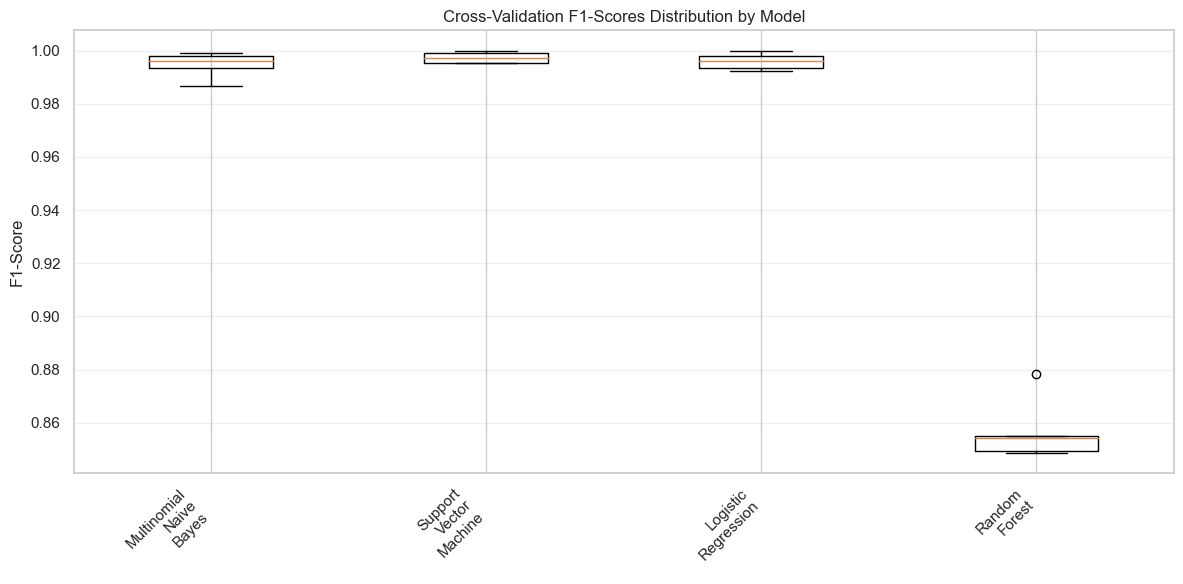


Top 3 models selected for hyperparameter tuning:
1. Support Vector Machine: 0.9974
2. Logistic Regression: 0.9961
3. Multinomial Naive Bayes: 0.9947


In [74]:
# Initialize stratified K-fold cross-validation with 5 folds to ensure each diagnostic category appears proportionally in every fold for robust model evaluation
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Combine training and validation sets for cross-validation to use all available data for more comprehensive model evaluation
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# Transform combined data using TF-IDF vectorization to convert text into numerical features that machine learning models can process
X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)

# Store cross-validation results in a dictionary to track performance metrics for each model across all folds
cv_results = {}

print("Performing K-Fold Cross-Validation...")
print("="*60)

# Evaluate each machine learning model using cross-validation to get reliable performance estimates
for model_name, model in candidate_models.items():
    print(f"\nEvaluating {model_name}...")
    
    # Perform cross-validation using F1-weighted scoring (balances precision and recall across all diagnostic categories) with parallel processing
    cv_scores = cross_val_score(model, X_train_val_tfidf, y_train_val, 
                               cv=skf, scoring='f1_weighted', n_jobs=-1)
    
    # Store comprehensive results including individual fold scores and statistical measures for detailed analysis
    cv_results[model_name] = {
        'scores': cv_scores,
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'min': cv_scores.min(),
        'max': cv_scores.max()
    }
    
    # Display mean F1-score with confidence interval (±2 standard deviations covers ~95% of expected performance range)
    print(f"F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"Individual fold scores: {cv_scores}")

# Create summary table with all cross-validation statistics for easy comparison between models
cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean_F1': [results['mean'] for results in cv_results.values()],
    'Std_F1': [results['std'] for results in cv_results.values()],
    'Min_F1': [results['min'] for results in cv_results.values()],
    'Max_F1': [results['max'] for results in cv_results.values()]
}).round(4)

# Sort by mean F1-score in descending order to identify the best performing models at the top
cv_summary = cv_summary.sort_values('Mean_F1', ascending=False)

print(f"\n{k_folds}-Fold Cross-Validation Results Summary:")
print("="*60)
print(cv_summary.to_string(index=False))

# Visualize cross-validation results using box plots to show performance distribution and identify models with consistent performance
plt.figure(figsize=(12, 6))
models = list(cv_results.keys())
scores = [cv_results[model]['scores'] for model in models]

# Create box plots with rotated labels to clearly show F1-score distributions for each model across all folds
plt.boxplot(scores, labels=[model.replace(' ', '\n') for model in models])
plt.title('Cross-Validation F1-Scores Distribution by Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)  # Add horizontal grid lines for easier score reading
plt.tight_layout()
plt.show()

# Select top performing models for hyperparameter tuning to focus computational resources on the most promising algorithms
top_models = cv_summary.head(3)['Model'].tolist()
print(f"\nTop 3 models selected for hyperparameter tuning:")
for i, model in enumerate(top_models, 1):
    mean_score = cv_results[model]['mean']
    print(f"{i}. {model}: {mean_score:.4f}")

#### 5.1.2 Hyperparameter Tuning

**Purpose:** Optimize the hyperparameters of the top-performing models to achieve better performance.

##### 5.1.2.1 Optimize Model Settings: Define Hyperparameter Grids

**Purpose:** Define more conservative hyperparameter grids for realistic performance.

In [75]:
# Define hyperparameter grids for realistic performance
# Hyperparameters are settings that control how machine learning algorithms learn from data
# We test different combinations to find the best settings for each model type
hyperparameter_grids = {
    # Multinomial Naive Bayes: A probabilistic classifier good for text classification
    'Multinomial Naive Bayes': {
        'alpha': [0.1, 0.5, 1.0, 2.0],  # Smoothing parameter - higher values prevent overfitting to rare words
        'fit_prior': [True, False]  # Whether to learn class probabilities from data (True) or assume equal probabilities (False)
    },
    # Logistic Regression: A linear model that uses probability to make classifications
    'Logistic Regression': {
        'C': [0.1, 1.0, 10.0],  # Regularization strength - smaller values mean stronger regularization to prevent overfitting
        'solver': ['liblinear', 'lbfgs'],  # Algorithm used to optimize the model - different solvers work better with different penalty types
        'penalty': ['l1', 'l2'],  # Type of regularization - l1 removes unimportant features, l2 shrinks all feature weights
        'max_iter': [1000]  # Maximum number of iterations for the solver to converge to a solution
    },
    # Support Vector Machine: Creates decision boundaries to separate different classes
    'Support Vector Machine': {
        'C': [0.1, 1.0, 10.0],  # Regularization parameter - controls trade-off between smooth decision boundary and classifying training points correctly
        'loss': ['hinge', 'squared_hinge'],  # Loss function used - hinge is standard SVM loss, squared_hinge is smoother version
        'max_iter': [5000]  # Maximum iterations to prevent infinite training time
    },
    # Random Forest: Combines many decision trees to make more robust predictions
    'Random Forest': {
        'n_estimators': [50, 100],  # Number of decision trees in the forest - more trees usually mean better performance but slower training
        'max_depth': [10, 20, None],  # Maximum depth of each tree - deeper trees can capture more complex patterns but may overfit
        'min_samples_split': [2, 5],  # Minimum samples required to split an internal node - higher values prevent overfitting
        'min_samples_leaf': [1, 2]  # Minimum samples required to be at a leaf node - higher values create smoother decision boundaries
    }
}

# Filter grids for only top performing models
# Only test hyperparameters for models that performed well in initial cross-validation to save computational time
selected_grids = {model: hyperparameter_grids[model] for model in top_models 
                 if model in hyperparameter_grids}

print("Hyperparameter grids defined for realistic performance:")
for model_name, grid in selected_grids.items():
    print(f"\n{model_name}:")
    for param, values in grid.items():
        print(f"  {param}: {values}")

Hyperparameter grids defined for realistic performance:

Support Vector Machine:
  C: [0.1, 1.0, 10.0]
  loss: ['hinge', 'squared_hinge']
  max_iter: [5000]

Logistic Regression:
  C: [0.1, 1.0, 10.0]
  solver: ['liblinear', 'lbfgs']
  penalty: ['l1', 'l2']
  max_iter: [1000]

Multinomial Naive Bayes:
  alpha: [0.1, 0.5, 1.0, 2.0]
  fit_prior: [True, False]


##### 5.1.2.2 Grid Search: Systematically Explore Hyperparameter Combinations

**Purpose:** Use GridSearchCV to explore different combinations of hyperparameter values systematically.

In [76]:
# Perform grid search for each top model
# Grid search systematically tests different combinations of hyperparameters to find the best settings
best_models = {}  # Dictionary to store the best-performing model for each algorithm type
grid_search_results = {}  # Dictionary to store detailed results including scores and parameters for each model

print("Performing Grid Search for Hyperparameter Optimization...")
print("="*70)

# Loop through each model that performed well in initial cross-validation testing
for model_name in top_models:
    # Only proceed if we have defined hyperparameter combinations to test for this model
    if model_name in selected_grids:
        print(f"\nOptimizing {model_name}...")
        
        # Get base model
        base_model = candidate_models[model_name]  # Retrieve the original untrained model instance
        param_grid = selected_grids[model_name]  # Get the hyperparameter combinations to test
        
        # Handle special case for Logistic Regression penalty-solver compatibility
        # Different penalty types (l1/l2) only work with specific solvers, so we need separate searches
        if model_name == 'Logistic Regression':
            # Create separate grids for different solver-penalty combinations
            grid_results = []  # Initialize empty list to collect results from multiple searches
            
            # L1 penalty only works with liblinear and saga
            # L1 regularization removes unimportant features by setting their weights to zero
            l1_grid = {
                'C': param_grid['C'],  # Regularization strength values to test
                'solver': ['liblinear'],  # Only solver compatible with L1 penalty
                'penalty': ['l1'],  # L1 regularization type
                'max_iter': param_grid['max_iter']  # Maximum training iterations
            }
            
            # L2 penalty works with both solvers
            # L2 regularization shrinks all feature weights but doesn't remove features completely
            l2_grid = {
                'C': param_grid['C'],  # Same regularization strength values
                'solver': ['liblinear', 'lbfgs'],  # Both solvers work with L2 penalty
                'penalty': ['l2'],  # L2 regularization type
                'max_iter': param_grid['max_iter']  # Maximum training iterations
            }
            
            # Search L1 grid
            # GridSearchCV tests all parameter combinations using cross-validation
            grid_search_l1 = GridSearchCV(
                base_model, l1_grid, cv=3, scoring='f1_weighted',  # Use 3-fold cross-validation with weighted F1 score
                n_jobs=-1, verbose=1  # Use all CPU cores and show progress
            )
            grid_search_l1.fit(X_train_val_tfidf, y_train_val)  # Train on combined training+validation data
            
            # Search L2 grid  
            # Perform separate grid search for L2 penalty combinations
            grid_search_l2 = GridSearchCV(
                base_model, l2_grid, cv=3, scoring='f1_weighted',  # Same settings as L1 search
                n_jobs=-1, verbose=1
            )
            grid_search_l2.fit(X_train_val_tfidf, y_train_val)  # Train on same data for fair comparison
            
            # Select best between L1 and L2
            # Compare the best scores from both searches and choose the superior approach
            if grid_search_l1.best_score_ > grid_search_l2.best_score_:
                grid_search = grid_search_l1  # L1 penalty performed better
            else:
                grid_search = grid_search_l2  # L2 penalty performed better
        else:
            # Standard grid search for other models
            # Most models don't have solver-penalty compatibility issues like Logistic Regression
            grid_search = GridSearchCV(
                base_model, param_grid, cv=3, scoring='f1_weighted',  # Test all parameter combinations
                n_jobs=-1, verbose=1  # Use all available CPU cores and show progress
            )
            grid_search.fit(X_train_val_tfidf, y_train_val)  # Train model with all parameter combinations
        
        # Store results
        # Save the best model and its performance metrics for later comparison
        best_models[model_name] = grid_search.best_estimator_  # Best-performing model with optimal parameters
        grid_search_results[model_name] = {
            'best_score': grid_search.best_score_,  # Highest F1 score achieved during grid search
            'best_params': grid_search.best_params_,  # Parameter combination that achieved best score
            'cv_results': grid_search.cv_results_  # Detailed results from all parameter combinations tested
        }
        
        # Display results for this model
        print(f"Best F1-Score: {grid_search.best_score_:.4f}")  # Show best performance with 4 decimal places
        print(f"Best Parameters: {grid_search.best_params_}")  # Show optimal parameter settings

# Summary of hyperparameter tuning results
# Create a comprehensive comparison table of all optimized models
print(f"\nHyperparameter Tuning Results Summary:")
print("="*50)

# Create DataFrame to compare model performance before and after hyperparameter tuning
tuning_summary = pd.DataFrame({
    'Model': list(grid_search_results.keys()),  # Model names
    'Best_F1_Score': [results['best_score'] for results in grid_search_results.values()],  # Best F1 scores after tuning
    'Improvement': [
        # Calculate improvement: (tuned score) - (original cross-validation score)
        grid_search_results[model]['best_score'] - cv_results[model]['mean'] 
        for model in grid_search_results.keys()
    ]
}).round(4)  # Round all numeric values to 4 decimal places for clean display

# Sort models by performance with best model at top
tuning_summary = tuning_summary.sort_values('Best_F1_Score', ascending=False)
print(tuning_summary.to_string(index=False))  # Display table without row indices

# Select the best model overall
# Choose the model with highest F1 score after hyperparameter optimization
best_model_name = tuning_summary.iloc[0]['Model']  # Get name of top-performing model
best_model = best_models[best_model_name]  # Retrieve the actual trained model object
best_score = tuning_summary.iloc[0]['Best_F1_Score']  # Get the best F1 score achieved

# Display final selection results
print(f"\n SELECTED BEST MODEL: {best_model_name}")  # Announce the winning model
print(f"   Cross-validation F1-Score: {best_score:.4f}")  # Show its performance score
print(f"   Optimized Parameters: {grid_search_results[best_model_name]['best_params']}")  # Show optimal settings

Performing Grid Search for Hyperparameter Optimization...

Optimizing Support Vector Machine...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best F1-Score: 0.9955
Best Parameters: {'C': 10.0, 'loss': 'hinge', 'max_iter': 5000}

Optimizing Logistic Regression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best F1-Score: 0.9955
Best Parameters: {'C': 10.0, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}

Optimizing Multinomial Naive Bayes...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best F1-Score: 0.9921
Best Parameters: {'alpha': 0.1, 'fit_prior': False}

Hyperparameter Tuning Results Summary:
                  Model  Best_F1_Score  Improvement
 Support Vector Machine         0.9955      -0.0019
    Logistic Regression         0.9955      -0.0006
Multinomial Naive Bayes         0.9921      -0.0026

 SELECTED BEST MODEL: Support Vector Machine
   Cross-validation F1-Score

#### 5.1.2.3 Cross-Validation within Tuning: Validate Hyperparameter Selection

**Purpose:** The GridSearchCV already incorporates cross-validation. Let's verify the stability of our best model with additional validation.

Additional Cross-Validation for Best Model: Support Vector Machine
10-Fold CV F1-Scores: [1.         1.         0.99812159 0.99624648 1.         0.99812159
 0.99437552 0.99624193 0.9962406  0.99434796]
Mean: 0.9974
Standard Deviation: 0.0021
95% Confidence Interval: [0.9933, 1.0015]


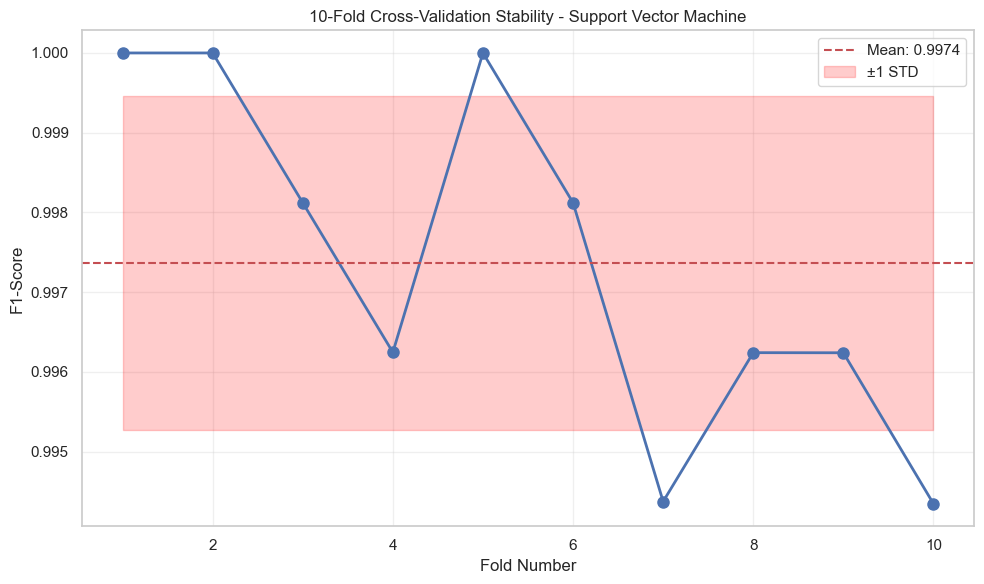


Model Stability Assessment: Stable
Coefficient of Variation: 0.21%


In [78]:
# Perform additional cross-validation on the best model to ensure stability
print(f"Additional Cross-Validation for Best Model: {best_model_name}")
print("="*60)

# Use 10-fold CV for more robust validation - divides data into 10 parts, trains on 9, tests on 1, repeats 10 times for reliable performance estimate
extended_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
# Calculate F1-scores across all 10 folds using parallel processing (-1 uses all CPU cores) to measure model consistency
extended_scores = cross_val_score(best_model, X_train_val_tfidf, y_train_val, 
                                                 cv=extended_cv, scoring='f1_weighted', n_jobs=-1)

print(f"10-Fold CV F1-Scores: {extended_scores}")
print(f"Mean: {extended_scores.mean():.4f}")
print(f"Standard Deviation: {extended_scores.std():.4f}")
# Calculate 95% confidence interval using 1.96 standard deviations (covers 95% of expected performance range)
print(f"95% Confidence Interval: [{extended_scores.mean() - 1.96*extended_scores.std():.4f}, "
        f"{extended_scores.mean() + 1.96*extended_scores.std():.4f}]")

# Visualize the stability
plt.figure(figsize=(10, 6))
# Plot F1-scores for each fold as blue circles connected by lines to show performance variation across folds
plt.plot(range(1, 11), extended_scores, 'bo-', linewidth=2, markersize=8)
# Add horizontal dashed red line showing the mean performance across all folds for reference
plt.axhline(y=extended_scores.mean(), color='r', linestyle='--', 
               label=f'Mean: {extended_scores.mean():.4f}')
# Add shaded area showing ±1 standard deviation from mean to visualize performance stability range
plt.fill_between(range(1, 11), 
                        extended_scores.mean() - extended_scores.std(),
                        extended_scores.mean() + extended_scores.std(),
                        alpha=0.2, color='red', label='±1 STD')
plt.title(f'10-Fold Cross-Validation Stability - {best_model_name}')
plt.xlabel('Fold Number')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check if model performance is consistent - categorize stability based on standard deviation thresholds
cv_stability = "Stable" if extended_scores.std() < 0.02 else "Moderate" if extended_scores.std() < 0.05 else "Unstable"
print(f"\nModel Stability Assessment: {cv_stability}")
# Calculate coefficient of variation (std/mean * 100) to measure relative variability as percentage
print(f"Coefficient of Variation: {(extended_scores.std() / extended_scores.mean()) * 100:.2f}%")

### 5.2 Deep Learning Models

**Purpose:** Select and configure deep learning models for text classification, including Convolutional Neural Networks (CNN), Feedforward Neural Networks (FNN), Recurrent Neural Networks (RNN) with appropriate hyperparameters to prevent overfitting.

In [79]:
# Prepare text data for deep learning models
print("Preparing text data for Deep Learning models...")

# Tokenize text for neural networks
max_features = 5000  # Maximum number of words to keep - limits vocabulary size to prevent overfitting and reduce memory usage
max_length = 100     # Maximum sequence length - standardizes all text inputs to same length for neural network processing

# Create tokenizer
tokenizer_dl = Tokenizer(num_words=max_features, oov_token="<OOV>")  # Creates tokenizer that converts text to numbers, handles unknown words with <OOV> token
tokenizer_dl.fit_on_texts(X_train_val)  # Learns vocabulary from training data to create word-to-number mapping dictionary

# Convert texts to sequences
X_train_val_seq = tokenizer_dl.texts_to_sequences(X_train_val)  # Transforms text into sequences of numbers based on learned vocabulary
X_test_seq = tokenizer_dl.texts_to_sequences(X_test)  # Applies same word-to-number mapping to test data for consistency

# Pad sequences
X_train_val_padded = pad_sequences(X_train_val_seq, maxlen=max_length, padding='post', truncating='post')  # Makes all sequences exactly 100 numbers long by adding zeros at end or cutting off excess
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')  # Ensures test sequences have same length as training for neural network compatibility

# Convert labels to categorical
num_classes = len(label_encoder.classes_)  # Counts total number of diagnostic categories (25 different medical conditions)
y_train_val_cat = to_categorical(y_train_val, num_classes=num_classes)  # Converts single numbers (0-24) to one-hot encoded vectors for multi-class classification
y_test_cat = to_categorical(y_test, num_classes=num_classes)  # Transforms test labels to same one-hot format required by neural networks

print(f"Sequence shape: {X_train_val_padded.shape}")  # Shows dimensions of processed training data (number of samples × sequence length)
print(f"Number of classes: {num_classes}")  # Displays total diagnostic categories the model will predict
print(f"Max sequence length: {max_length}")  # Confirms standardized text length for neural network input
print(f"Vocabulary size: {max_features}")  # Shows size of word dictionary used for text-to-number conversion

Preparing text data for Deep Learning models...
Sequence shape: (5328, 100)
Number of classes: 25
Max sequence length: 100
Vocabulary size: 5000


In [82]:
# Define deep learning model creation functions
def create_cnn_model(vocab_size, embedding_dim=64, max_length=100, num_classes=25, 
                     filters=64, kernel_size=3, dropout_rate=0.3):
    """Create CNN model for text classification"""
    model = Sequential([
        # Convert word indices to dense vectors of fixed size - learns word relationships during training
        Embedding(vocab_size, embedding_dim, input_length=max_length),
        # Apply 1D convolution to detect local patterns in text sequences (like n-grams or phrases)
        Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
        # Extract the most important feature from each filter across the entire sequence
        GlobalMaxPooling1D(),
        # First fully connected layer to learn complex feature combinations with ReLU activation
        Dense(128, activation='relu'),
        # Randomly set 30% of neurons to zero during training to prevent overfitting
        Dropout(dropout_rate),
        # Second fully connected layer with fewer neurons to gradually reduce complexity
        Dense(64, activation='relu'),
        # Another dropout layer for additional regularization against overfitting
        Dropout(dropout_rate),
        # Final output layer with softmax activation to produce probability distribution over 25 diagnostic categories
        Dense(num_classes, activation='softmax')
    ])
    
    # Configure the model's learning process with optimizer, loss function, and evaluation metric
    model.compile(
        optimizer='adam',  # Adaptive learning rate optimizer that adjusts automatically during training
        loss='categorical_crossentropy',  # Loss function for multi-class classification with one-hot encoded labels
        metrics=['accuracy']  # Track accuracy percentage during training and validation
    )
    return model

def create_feedforward_model(vocab_size, embedding_dim=64, max_length=100, num_classes=25,
                           hidden_units=128, dropout_rate=0.3):
    """Create Feedforward Neural Network model"""
    model = Sequential([
        # Convert word indices to dense vectors - same as CNN but for feedforward architecture
        Embedding(vocab_size, embedding_dim, input_length=max_length),
        # Average all word embeddings in the sequence to create a single fixed-size representation
        GlobalMaxPooling1D(),
        # First hidden layer to learn complex patterns from the averaged word embeddings
        Dense(hidden_units, activation='relu'),
        # Dropout for regularization to prevent the model from memorizing training data
        Dropout(dropout_rate),
        # Second hidden layer with half the neurons to create a funnel-like architecture
        Dense(hidden_units // 2, activation='relu'),
        # Additional dropout layer to further reduce overfitting risk
        Dropout(dropout_rate),
        # Output layer that converts learned features into probabilities for each diagnostic category
        Dense(num_classes, activation='softmax')
    ])
    
    # Set up the training configuration with standard settings for multi-class text classification
    model.compile(
        optimizer='adam',  # Efficient gradient descent algorithm with adaptive learning rates
        loss='categorical_crossentropy',  # Standard loss for predicting one category from multiple options
        metrics=['accuracy']  # Monitor classification accuracy during model training
    )
    return model

def create_rnn_model(vocab_size, embedding_dim=64, max_length=100, num_classes=25,
                     rnn_units=64, dropout_rate=0.3):
    """Create RNN model for text classification"""
    model = Sequential([
        # Convert word indices to dense vectors that capture semantic word relationships
        Embedding(vocab_size, embedding_dim, input_length=max_length),
        # LSTM layer that processes text sequentially, remembering important information across the sequence
        tf.keras.layers.LSTM(rnn_units, dropout=dropout_rate, recurrent_dropout=dropout_rate),
        # Dense layer to transform LSTM output into a format suitable for classification
        Dense(64, activation='relu'),
        # Dropout to prevent overfitting by randomly ignoring some neurons during training
        Dropout(dropout_rate),
        # Final classification layer that outputs probability scores for each of the 25 medical conditions
        Dense(num_classes, activation='softmax')
    ])
    
    # Configure the model's training process with appropriate settings for sequence classification
    model.compile(
        optimizer='adam',  # Advanced optimizer that automatically adjusts learning speed for better convergence
        loss='categorical_crossentropy',  # Loss function designed for multi-class problems with mutually exclusive categories
        metrics=['accuracy']  # Track the percentage of correctly classified medical symptoms
    )
    return model

# Initialize candidate deep learning models
# Dictionary mapping model names to their creation functions for easy iteration and comparison
dl_model_creators = {
    'Convolutional Neural Network': create_cnn_model,  # CNN excels at detecting local patterns in text
    'Feedforward Neural Network': create_feedforward_model,  # Simple architecture good for baseline performance
    'Recurrent Neural Network': create_rnn_model  # RNN captures sequential dependencies in symptom descriptions
}

print("Deep Learning Model Architectures:")
for name in dl_model_creators.keys():
    print(f"✓ {name}")
    
print(f"\nTotal DL models to evaluate: {len(dl_model_creators)}")

Deep Learning Model Architectures:
✓ Convolutional Neural Network
✓ Feedforward Neural Network
✓ Recurrent Neural Network

Total DL models to evaluate: 3


#### 5.2.1 DL K-fold Cross Validation

**Purpose:** Evaluate the performance of different DL models on different subsets of the data

Performing K-Fold Cross-Validation for Deep Learning Models...

Evaluating Convolutional Neural Network...
  Fold 1/3...
    Fold 1 F1-Score: 0.9989
  Fold 2/3...
    Fold 2 F1-Score: 0.9983
  Fold 3/3...
    Fold 3 F1-Score: 0.9949
  Average F1-Score: 0.9974 (+/- 0.0035)

Evaluating Feedforward Neural Network...
  Fold 1/3...
    Fold 1 F1-Score: 0.9989
  Fold 2/3...
    Fold 2 F1-Score: 0.9983
  Fold 3/3...
    Fold 3 F1-Score: 0.9932
  Average F1-Score: 0.9968 (+/- 0.0051)

Evaluating Recurrent Neural Network...
  Fold 1/3...
    Fold 1 F1-Score: 0.0046
  Fold 2/3...
    Fold 2 F1-Score: 0.0046
  Fold 3/3...
    Fold 3 F1-Score: 0.0047
  Average F1-Score: 0.0046 (+/- 0.0001)

3-Fold Cross-Validation Results Summary (Deep Learning):
                       Model  Mean_F1  Std_F1  Min_F1  Max_F1
Convolutional Neural Network   0.9974  0.0017  0.9949  0.9989
  Feedforward Neural Network   0.9968  0.0025  0.9932  0.9989
    Recurrent Neural Network   0.0046  0.0000  0.0046  0.0047


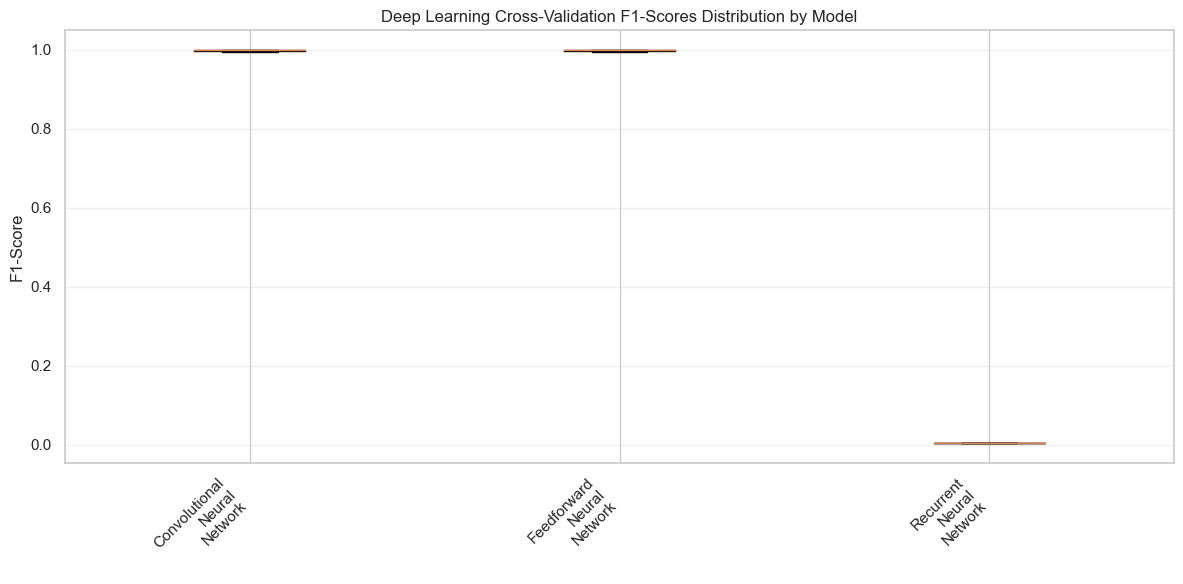


Top 2 DL models selected for hyperparameter tuning:
1. Convolutional Neural Network: 0.9974
2. Feedforward Neural Network: 0.9968


In [83]:
# Initialize stratified K-fold cross-validation for deep learning
k_folds_dl = 3  # Reduced folds for DL due to computational cost
skf_dl = StratifiedKFold(n_splits=k_folds_dl, shuffle=True, random_state=42)

# Store cross-validation results for deep learning
dl_cv_results = {}

print("Performing K-Fold Cross-Validation for Deep Learning Models...")
print("="*70)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=0
)

# Loop through each deep learning model creator function to evaluate performance using cross-validation
for model_name, model_creator in dl_model_creators.items():
    print(f"\nEvaluating {model_name}...")
    
    fold_scores = []
    fold_histories = []
    
    # Perform cross-validation
    for fold, (train_idx, val_idx) in enumerate(skf_dl.split(X_train_val_padded, y_train_val)):
        print(f"  Fold {fold + 1}/{k_folds_dl}...")
        
        # Split data for this fold
        X_fold_train, X_fold_val = X_train_val_padded[train_idx], X_train_val_padded[val_idx]
        y_fold_train, y_fold_val = y_train_val_cat[train_idx], y_train_val_cat[val_idx]
        
        # Create and train model
        model = model_creator(
            vocab_size=max_features,
            embedding_dim=64,
            max_length=max_length,
            num_classes=num_classes
        )
        
        # Train model
        history = model.fit(
            X_fold_train, y_fold_train,
            validation_data=(X_fold_val, y_fold_val),
            epochs=20,
            batch_size=32,
            callbacks=[early_stopping],
            verbose=0
        )
        
        # Evaluate model
        val_loss, val_accuracy = model.evaluate(X_fold_val, y_fold_val, verbose=0)
        
        # Calculate F1-score
        y_pred = model.predict(X_fold_val, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probability predictions to class predictions by finding the highest probability class
        y_true_classes = np.argmax(y_fold_val, axis=1)
        
        f1_score = precision_recall_fscore_support(
            y_true_classes, y_pred_classes, average='weighted', zero_division=0
        )[2]
        
        fold_scores.append(f1_score)
        fold_histories.append(history)
        
        print(f"    Fold {fold + 1} F1-Score: {f1_score:.4f}")
    
    # Store results
    fold_scores = np.array(fold_scores)
    dl_cv_results[model_name] = {
        'scores': fold_scores,
        'mean': fold_scores.mean(),
        'std': fold_scores.std(),
        'min': fold_scores.min(),
        'max': fold_scores.max(),
        'histories': fold_histories
    }
    
    print(f"  Average F1-Score: {fold_scores.mean():.4f} (+/- {fold_scores.std() * 2:.4f})")

# Create summary table for deep learning models
dl_cv_summary = pd.DataFrame({
    'Model': list(dl_cv_results.keys()),
    'Mean_F1': [results['mean'] for results in dl_cv_results.values()],
    'Std_F1': [results['std'] for results in dl_cv_results.values()],
    'Min_F1': [results['min'] for results in dl_cv_results.values()],
    'Max_F1': [results['max'] for results in dl_cv_results.values()]
}).round(4)

# Sort by mean F1-score
dl_cv_summary = dl_cv_summary.sort_values('Mean_F1', ascending=False)

print(f"\n{k_folds_dl}-Fold Cross-Validation Results Summary (Deep Learning):")
print("="*70)
print(dl_cv_summary.to_string(index=False))

# Visualize deep learning cross-validation results
plt.figure(figsize=(12, 6))
models_dl = list(dl_cv_results.keys())
scores_dl = [dl_cv_results[model]['scores'] for model in models_dl]

plt.boxplot(scores_dl, labels=[model.replace(' ', '\n') for model in models_dl])
plt.title('Deep Learning Cross-Validation F1-Scores Distribution by Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Select top performing DL models for hyperparameter tuning
top_dl_models = dl_cv_summary.head(2)['Model'].tolist()
print(f"\nTop 2 DL models selected for hyperparameter tuning:")
for i, model in enumerate(top_dl_models, 1):
    mean_score = dl_cv_results[model]['mean']
    print(f"{i}. {model}: {mean_score:.4f}")

#### 5.2.2 Hyperparameter Tuning

**Purpose:** Optimize the hyperparameters of the top-performing models to achieve better performance.

##### 5.2.2.1 Optimize Model Settings: Define Hyperparameter Grids

**Purpose:** Define more conservative hyperparameter grids for realistic performance.

In [85]:
# Define hyperparameter grids for deep learning models
# These grids contain different combinations of parameters that control how neural networks learn
# We'll test different values to find the best settings for each model type
dl_hyperparameter_grids = {
    # CNN (Convolutional Neural Network) - good at detecting patterns in text sequences
    'Convolutional Neural Network': {
        'embedding_dim': [32, 64],  # Size of word vector representations (32 or 64 dimensions)
        'filters': [32, 64],  # Number of feature detectors to find text patterns
        'kernel_size': [3, 5],  # Size of text window each filter examines (3 or 5 words at once)
        'dropout_rate': [0.2, 0.3]  # Percentage of neurons to randomly ignore during training to prevent overfitting
    },
    # FNN (Feedforward Neural Network) - simple architecture that processes all words at once
    'Feedforward Neural Network': {
        'embedding_dim': [32, 64],  # Size of word vector representations (same as CNN)
        'hidden_units': [64, 128],  # Number of neurons in the hidden layer that learns complex patterns
        'dropout_rate': [0.2, 0.3]  # Regularization to prevent memorizing training data
    },
    # RNN (Recurrent Neural Network) - processes text word by word, remembering previous context
    'Recurrent Neural Network': {
        'embedding_dim': [32, 64],  # Size of word vector representations (consistent across all models)
        'rnn_units': [32, 64],  # Number of memory cells that remember information across the text sequence
        'dropout_rate': [0.2, 0.3]  # Prevents overfitting by randomly dropping connections during training
    }
}

# Filter grids for only top performing DL models
# Only create parameter grids for models that performed well in cross-validation to save computational time
selected_dl_grids = {model: dl_hyperparameter_grids[model] for model in top_dl_models 
                    if model in dl_hyperparameter_grids}

print("Deep Learning hyperparameter grids defined for realistic performance:")
for model_name, grid in selected_dl_grids.items():
    print(f"\n{model_name}:")
    for param, values in grid.items():
        print(f"  {param}: {values}")

Deep Learning hyperparameter grids defined for realistic performance:

Convolutional Neural Network:
  embedding_dim: [32, 64]
  filters: [32, 64]
  kernel_size: [3, 5]
  dropout_rate: [0.2, 0.3]

Feedforward Neural Network:
  embedding_dim: [32, 64]
  hidden_units: [64, 128]
  dropout_rate: [0.2, 0.3]


##### 5.2.2.2 Grid Search: Systematically Explore Hyperparameter Combinations

**Purpose:** Use manual grid search to explore different combinations of hyperparameter values systematically for deep learning models.

In [86]:
# Perform manual grid search for deep learning models
# Initialize dictionaries to store the best models and their grid search results
best_dl_models = {}
dl_grid_search_results = {}

print("Performing Grid Search for Deep Learning Hyperparameter Optimization...")
print("="*80)

def evaluate_dl_model_params(model_creator, params, model_name):
    """Evaluate a deep learning model with specific parameters using cross-validation"""
    scores = []
    
    # Use 2-fold CV for faster evaluation (fewer splits = faster training but less robust validation)
    skf_tuning = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    
    # Split the training data into smaller train/validation sets for hyperparameter testing
    for train_idx, val_idx in skf_tuning.split(X_train_val_padded, y_train_val):
        # Split data
        X_fold_train, X_fold_val = X_train_val_padded[train_idx], X_train_val_padded[val_idx]
        y_fold_train, y_fold_val = y_train_val_cat[train_idx], y_train_val_cat[val_idx]
        
        # Create model with parameters
        model = model_creator(
            vocab_size=max_features,
            max_length=max_length,
            num_classes=num_classes,
            **params
        )
        
        # Train model
        history = model.fit(
            X_fold_train, y_fold_train,
            validation_data=(X_fold_val, y_fold_val),
            epochs=15,  # Reduced epochs for tuning
            batch_size=32,
            callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
            verbose=0
        )
        
        # Evaluate
        y_pred = model.predict(X_fold_val, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true_classes = np.argmax(y_fold_val, axis=1)
        
        f1_score = precision_recall_fscore_support(
            y_true_classes, y_pred_classes, average='weighted', zero_division=0
        )[2]
        
        scores.append(f1_score)
    
    return np.mean(scores)

# Perform grid search for each top DL model
for model_name in top_dl_models:
    if model_name in selected_dl_grids:
        print(f"\nOptimizing {model_name}...")
        
        model_creator = dl_model_creators[model_name]
        param_grid = selected_dl_grids[model_name]
        
        # Generate all parameter combinations using itertools.product (creates cartesian product of all parameter lists)
        from itertools import product
        param_names = list(param_grid.keys())
        param_values = list(param_grid.values())
        param_combinations = list(product(*param_values))
        
        best_score = 0
        best_params = {}
        
        print(f"  Testing {len(param_combinations)} parameter combinations...")
        
        # Test each parameter combination to find the best one
        for i, param_combo in enumerate(param_combinations):
            params = dict(zip(param_names, param_combo))
            
            try:
                score = evaluate_dl_model_params(model_creator, params, model_name)
                print(f"    Combination {i+1}/{len(param_combinations)}: F1={score:.4f}, Params={params}")
                
                # Update best parameters if current score is better
                if score > best_score:
                    best_score = score  # Store the highest F1 score achieved so far
                    best_params = params  # Store the parameter combination that achieved this score
                    
            except Exception as e:
                print(f"    Combination {i+1}/{len(param_combinations)}: FAILED - {str(e)}")
                continue
        
        # Create best model with optimal parameters
        best_model = model_creator(
            vocab_size=max_features,
            max_length=max_length,
            num_classes=num_classes,
            **best_params
        )
        
        # Store results
        best_dl_models[model_name] = best_model
        dl_grid_search_results[model_name] = {
            'best_score': best_score,
            'best_params': best_params,
            'param_combinations_tested': len(param_combinations)
        }
        
        print(f"  Best F1-Score: {best_score:.4f}")
        print(f"  Best Parameters: {best_params}")

# Summary of deep learning hyperparameter tuning results
print(f"\nDeep Learning Hyperparameter Tuning Results Summary:")
print("="*60)

if dl_grid_search_results:
    # Create a summary DataFrame comparing all models' performance after hyperparameter tuning
    dl_tuning_summary = pd.DataFrame({
        'Model': list(dl_grid_search_results.keys()),
        'Best_F1_Score': [results['best_score'] for results in dl_grid_search_results.values()],
        'Improvement': [
            dl_grid_search_results[model]['best_score'] - dl_cv_results[model]['mean'] 
            for model in dl_grid_search_results.keys()
        ]
    }).round(4)

    # Sort models by performance (best F1-Score first)
    dl_tuning_summary = dl_tuning_summary.sort_values('Best_F1_Score', ascending=False)
    print(dl_tuning_summary.to_string(index=False))

    # Select the best DL model overall
    best_dl_model_name = dl_tuning_summary.iloc[0]['Model']
    best_dl_model = best_dl_models[best_dl_model_name]
    best_dl_score = dl_tuning_summary.iloc[0]['Best_F1_Score']

    print(f"\n SELECTED BEST DL MODEL: {best_dl_model_name}")
    print(f"   Cross-validation F1-Score: {best_dl_score:.4f}")
    print(f"   Optimized Parameters: {dl_grid_search_results[best_dl_model_name]['best_params']}")
else:
    print("No successful hyperparameter tuning results available.")
    # Fall back to best model from CV (use original cross-validation results as backup)
    best_dl_model_name = dl_cv_summary.iloc[0]['Model']
    best_dl_model = dl_model_creators[best_dl_model_name](
        vocab_size=max_features,
        max_length=max_length,
        num_classes=num_classes
    )
    best_dl_score = dl_cv_summary.iloc[0]['Mean_F1']
    print(f"\n FALLBACK BEST DL MODEL: {best_dl_model_name}")
    print(f"   Cross-validation F1-Score: {best_dl_score:.4f}")

Performing Grid Search for Deep Learning Hyperparameter Optimization...

Optimizing Convolutional Neural Network...
  Testing 16 parameter combinations...
    Combination 1/16: F1=0.9946, Params={'embedding_dim': 32, 'filters': 32, 'kernel_size': 3, 'dropout_rate': 0.2}
    Combination 2/16: F1=0.9962, Params={'embedding_dim': 32, 'filters': 32, 'kernel_size': 3, 'dropout_rate': 0.3}
    Combination 3/16: F1=0.9968, Params={'embedding_dim': 32, 'filters': 32, 'kernel_size': 5, 'dropout_rate': 0.2}
    Combination 4/16: F1=0.9946, Params={'embedding_dim': 32, 'filters': 32, 'kernel_size': 5, 'dropout_rate': 0.3}
    Combination 5/16: F1=0.9951, Params={'embedding_dim': 32, 'filters': 64, 'kernel_size': 3, 'dropout_rate': 0.2}
    Combination 6/16: F1=0.9968, Params={'embedding_dim': 32, 'filters': 64, 'kernel_size': 3, 'dropout_rate': 0.3}
    Combination 7/16: F1=0.9968, Params={'embedding_dim': 32, 'filters': 64, 'kernel_size': 5, 'dropout_rate': 0.2}
    Combination 8/16: F1=0.9959, 

#### 5.2.2.3 Cross-Validation within Tuning: Validate Hyperparameter Selection

**Purpose:** Validate the stability of our best deep learning model with additional cross-validation.

Additional Cross-Validation for Best DL Model: Convolutional Neural Network
Performing 5-fold cross-validation on best DL model...
  Fold 1/5...
    Fold 1 F1-Score: 1.0000
  Fold 2/5...
    Fold 2 F1-Score: 0.9972
  Fold 3/5...
    Fold 3 F1-Score: 0.9991
  Fold 4/5...
    Fold 4 F1-Score: 0.9944
  Fold 5/5...
    Fold 5 F1-Score: 0.9953

5-Fold CV F1-Scores: [1.         0.99718274 0.99906134 0.99437645 0.99529118]
Mean: 0.9972
Standard Deviation: 0.0021
95% Confidence Interval: [0.9930, 1.0014]


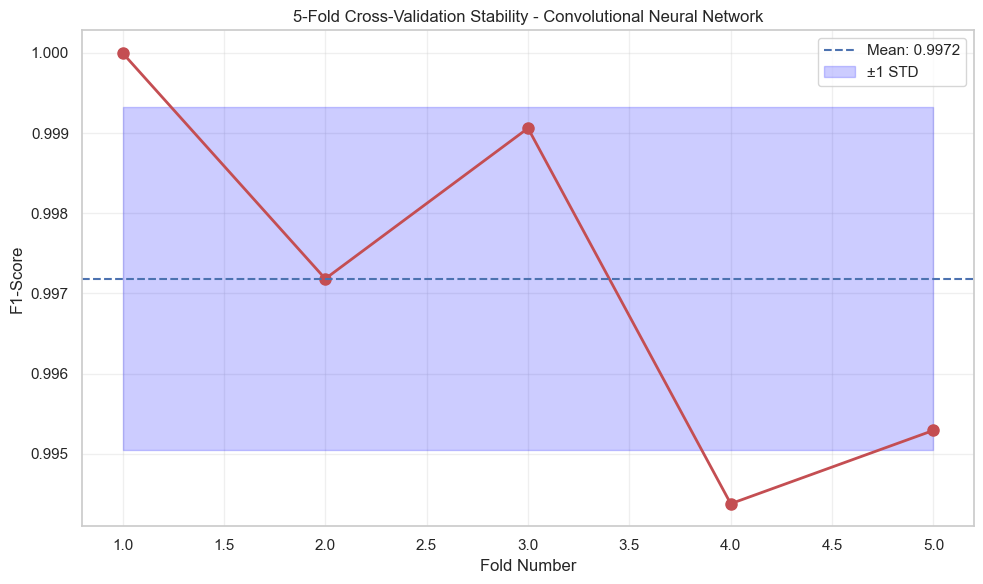


DL Model Stability Assessment: Stable
Coefficient of Variation: 0.21%

Training final Convolutional Neural Network on full training data...
Epoch 1/30
134/134 [==============================] - 2s 8ms/step - loss: 3.0582 - accuracy: 0.1333 - val_loss: 2.3692 - val_accuracy: 0.2842
Epoch 2/30
134/134 [==============================] - 1s 7ms/step - loss: 1.2828 - accuracy: 0.6473 - val_loss: 0.3616 - val_accuracy: 0.9390
Epoch 3/30
134/134 [==============================] - 1s 7ms/step - loss: 0.3268 - accuracy: 0.9266 - val_loss: 0.0795 - val_accuracy: 0.9944
Epoch 4/30
134/134 [==============================] - 1s 7ms/step - loss: 0.1347 - accuracy: 0.9775 - val_loss: 0.0380 - val_accuracy: 0.9981
Epoch 5/30
134/134 [==============================] - 1s 7ms/step - loss: 0.0869 - accuracy: 0.9862 - val_loss: 0.0255 - val_accuracy: 0.9981
Epoch 6/30
134/134 [==============================] - 1s 9ms/step - loss: 0.0626 - accuracy: 0.9904 - val_loss: 0.0230 - val_accuracy: 0.9991
Epoch 7

In [87]:
# Perform additional cross-validation on the best DL model to ensure stability
print(f"Additional Cross-Validation for Best DL Model: {best_dl_model_name}")
print("="*70)

# Use 5-fold CV for more robust validation of the final model
extended_cv_dl = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Create 5-fold cross-validation splitter that maintains class distribution proportions
extended_scores_dl = []

print("Performing 5-fold cross-validation on best DL model...")

for fold, (train_idx, val_idx) in enumerate(extended_cv_dl.split(X_train_val_padded, y_train_val)):  # Split data into 5 training/validation pairs for robust evaluation
    print(f"  Fold {fold + 1}/5...")
    
    # Split data for this fold
    X_fold_train, X_fold_val = X_train_val_padded[train_idx], X_train_val_padded[val_idx]  # Extract training and validation data for current fold using indices
    y_fold_train, y_fold_val = y_train_val_cat[train_idx], y_train_val_cat[val_idx]  # Extract corresponding labels (categorical encoded) for current fold
    
    # Create model (use best parameters if available)
    if best_dl_model_name in dl_grid_search_results:  # Check if hyperparameter tuning results exist for this model
        best_params = dl_grid_search_results[best_dl_model_name]['best_params']  # Retrieve optimal hyperparameters found during grid search
        model = dl_model_creators[best_dl_model_name](  # Create model instance using the constructor function with optimized parameters
            vocab_size=max_features,
            max_length=max_length,
            num_classes=num_classes,
            **best_params
        )
    else:
        model = dl_model_creators[best_dl_model_name](  # Create model with default parameters if no tuning was performed
            vocab_size=max_features,
            max_length=max_length,
            num_classes=num_classes
        )
    
    # Train model
    history = model.fit(  # Train the neural network model on current fold's training data
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=20,  # Maximum number of training iterations through the entire dataset
        batch_size=32,  # Number of samples processed before model weights are updated
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],  # Stop training early if validation loss doesn't improve for 3 epochs
        verbose=0  # Suppress training progress output for cleaner console display
    )
    
    # Evaluate model
    y_pred = model.predict(X_fold_val, verbose=0)  # Generate probability predictions for validation data (returns probabilities for each class)
    y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probability predictions to class labels by selecting highest probability class
    y_true_classes = np.argmax(y_fold_val, axis=1)  # Convert one-hot encoded true labels back to class indices for comparison
    
    f1_score = precision_recall_fscore_support(  # Calculate F1-score which balances precision and recall metrics
        y_true_classes, y_pred_classes, average='weighted', zero_division=0
    )[2]  # Extract F1-score from the returned tuple (precision, recall, f1, support)
    
    extended_scores_dl.append(f1_score)  # Store F1-score for this fold to calculate overall performance statistics
    print(f"    Fold {fold + 1} F1-Score: {f1_score:.4f}")

extended_scores_dl = np.array(extended_scores_dl)  # Convert list to numpy array for statistical calculations

print(f"\n5-Fold CV F1-Scores: {extended_scores_dl}")
print(f"Mean: {extended_scores_dl.mean():.4f}")  # Average F1-score across all folds indicates overall model performance
print(f"Standard Deviation: {extended_scores_dl.std():.4f}")  # Measures consistency of performance across folds (lower = more stable)
print(f"95% Confidence Interval: [{extended_scores_dl.mean() - 1.96*extended_scores_dl.std():.4f}, "  # Statistical range where true performance likely falls
      f"{extended_scores_dl.mean() + 1.96*extended_scores_dl.std():.4f}]")

# Visualize the stability
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), extended_scores_dl, 'ro-', linewidth=2, markersize=8)  # Plot F1-scores for each fold with red circles and lines
plt.axhline(y=extended_scores_dl.mean(), color='b', linestyle='--',   # Add horizontal line showing average performance across folds
           label=f'Mean: {extended_scores_dl.mean():.4f}')
plt.fill_between(range(1, 6),   # Shade area representing one standard deviation above and below mean
                extended_scores_dl.mean() - extended_scores_dl.std(),
                extended_scores_dl.mean() + extended_scores_dl.std(),
                alpha=0.2, color='blue', label='±1 STD')
plt.title(f'5-Fold Cross-Validation Stability - {best_dl_model_name}')
plt.xlabel('Fold Number')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True, alpha=0.3)  # Add light grid for easier reading of values
plt.tight_layout()
plt.show()

# Check if DL model performance is consistent
dl_cv_stability = "Stable" if extended_scores_dl.std() < 0.02 else "Moderate" if extended_scores_dl.std() < 0.05 else "Unstable"  # Classify model stability based on standard deviation thresholds
print(f"\nDL Model Stability Assessment: {dl_cv_stability}")
print(f"Coefficient of Variation: {(extended_scores_dl.std() / extended_scores_dl.mean()) * 100:.2f}%")  # Relative variability measure (lower percentage = more consistent)

# Train final best DL model on full training data for comparison
print(f"\nTraining final {best_dl_model_name} on full training data...")

# Create final model
if best_dl_model_name in dl_grid_search_results:  # Use optimized hyperparameters if available for final model training
    best_params = dl_grid_search_results[best_dl_model_name]['best_params']
    final_dl_model = dl_model_creators[best_dl_model_name](  # Create final model instance with best found parameters
        vocab_size=max_features,
        max_length=max_length,
        num_classes=num_classes,
        **best_params
    )
else:
    final_dl_model = dl_model_creators[best_dl_model_name](  # Create final model with default parameters
        vocab_size=max_features,
        max_length=max_length,
        num_classes=num_classes
    )

# Train on full training data
final_history = final_dl_model.fit(  # Train final model on complete training dataset for maximum learning
    X_train_val_padded, y_train_val_cat,
    validation_split=0.2,  # Reserve 20% of training data for validation during training process
    epochs=30,  # Allow more training epochs for final model to fully learn patterns
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],  # More patient early stopping for final training
    verbose=1  # Show training progress for final model training
)

# Evaluate on test set
test_loss, test_accuracy = final_dl_model.evaluate(X_test_padded, y_test_cat, verbose=0)  # Calculate loss and accuracy on unseen test data
y_test_pred = final_dl_model.predict(X_test_padded, verbose=0)  # Generate predictions for test set
y_test_pred_classes = np.argmax(y_test_pred, axis=1)  # Convert probability predictions to class predictions

# Calculate comprehensive metrics
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(  # Calculate detailed performance metrics on test set
    y_test, y_test_pred_classes, average='weighted', zero_division=0
)

print(f"\nFinal {best_dl_model_name} Test Set Performance:")
print(f"Test Accuracy: {test_accuracy:.4f}")  # Percentage of correctly classified test samples
print(f"Test Precision: {test_precision:.4f}")  # Proportion of positive predictions that were actually correct
print(f"Test Recall: {test_recall:.4f}")  # Proportion of actual positive cases that were correctly identified
print(f"Test F1-Score: {test_f1:.4f}")  # Harmonic mean of precision and recall, balancing both metrics

# Store final DL model results for comparison
final_dl_results = {  # Dictionary containing all important results for later comparison and analysis
    'model_name': best_dl_model_name,
    'model': final_dl_model,
    'test_accuracy': test_accuracy,
    'test_precision': test_precision,
    'test_recall': test_recall,
    'test_f1': test_f1,
    'cv_stability': dl_cv_stability,
    'cv_mean': extended_scores_dl.mean(),
    'cv_std': extended_scores_dl.std()
}

print(f"\nDeep Learning Model Selection Complete!")
print(f"Selected Model: {best_dl_model_name}")
print(f"Cross-validation F1: {extended_scores_dl.mean():.4f} (±{extended_scores_dl.std():.4f})")  # Summary of cross-validation performance with uncertainty measure
print(f"Test F1-Score: {test_f1:.4f}")  # Final performance on completely unseen test data

## 6. Model Training

**Purpose:** Train the selected best models on the full training dataset and prepare them for final evaluation.

In [90]:
# Train the final models on the full training dataset
print("FINAL MODEL TRAINING")
print("="*40)

# Initialize storage for trained models
final_trained_models = {}
final_model_results = {}

# 1. Train the best traditional ML models
print("\n1. Training Traditional ML Models...")
print("-" * 40)

# Use the best models from hyperparameter tuning if available
if 'best_models' in locals() and best_models:  # Check if hyperparameter-tuned models exist in current workspace
    ml_models_to_train = best_models
    print("Using hyperparameter-tuned models")
else:
    # Use default models with good parameters
    ml_models_to_train = {
        'Support Vector Machine': LinearSVC(C=10.0, max_iter=5000, random_state=42),  # Creates SVM classifier with regularization strength C=10.0 and maximum 5000 iterations
        'Logistic Regression': LogisticRegression(C=10.0, max_iter=1000, random_state=42),  # Creates logistic regression with regularization C=10.0 and max 1000 iterations for convergence
        'Multinomial Naive Bayes': MultinomialNB(alpha=0.1)  # Creates Naive Bayes classifier with smoothing parameter alpha=0.1 to handle zero probabilities
    }
    print("Using default models with optimized parameters")

# Ensure we have the combined training data
if 'X_train_val_tfidf' not in locals():  # Check if TF-IDF transformed training data exists
    print("Preparing TF-IDF features for combined training data...")
    X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)  # Convert text to numerical TF-IDF features for machine learning algorithms

# Train each traditional ML model
for model_name, model in ml_models_to_train.items():  # Iterate through each model type and its instance
    print(f"\nTraining {model_name}...")
    
    # Train on combined training+validation data
    model.fit(X_train_val_tfidf, y_train_val)  # Train the model using TF-IDF features as input and encoded labels as target
    
    # Store the trained model
    final_trained_models[model_name] = model  # Save trained model in dictionary for later evaluation and comparison
    
    # Evaluate on training data for monitoring
    train_pred = model.predict(X_train_val_tfidf)  # Generate predictions on training data to monitor model performance
    train_acc = accuracy_score(y_train_val, train_pred)  # Calculate accuracy by comparing true labels with predictions
    
    print(f"  Training accuracy: {train_acc:.4f}")
    print(f"  ✓ {model_name} training completed")

# 2. Train the best deep learning model
print("\n2. Training Deep Learning Model...")
print("-" * 40)

# Use the best DL model architecture and parameters
if 'best_dl_model_name' in locals():  # Check if a best deep learning model was identified from previous hyperparameter tuning
    dl_model_name = best_dl_model_name
    print(f"Using best DL model: {dl_model_name}")
    
    # Get the model creator function
    if dl_model_name in dl_model_creators:  # Check if model creation function exists for the specified model type
        model_creator = dl_model_creators[dl_model_name]  # Retrieve the function that creates the specific neural network architecture
        
        # Use optimized parameters if available
        if dl_model_name in dl_grid_search_results:  # Check if hyperparameter search results exist for this model
            best_params = dl_grid_search_results[dl_model_name]['best_params']  # Extract the best hyperparameters found during grid search
            print(f"Using optimized parameters: {best_params}")
            
            final_dl_model = model_creator(  # Create neural network with optimized hyperparameters
                vocab_size=max_features,  # Number of unique words in vocabulary (5000)
                max_length=max_length,  # Maximum sequence length for text padding (100)
                num_classes=num_classes,  # Number of medical condition categories to predict (25)
                **best_params  # Unpack optimized hyperparameters like embedding_dim, hidden_units, dropout_rate
            )
        else:
            print("Using default parameters")
            final_dl_model = model_creator(  # Create neural network with default hyperparameters
                vocab_size=max_features,
                max_length=max_length,
                num_classes=num_classes
            )
    else:
        print(f"Model creator not found for {dl_model_name}, using CNN")
        final_dl_model = create_cnn_model(  # Fallback to Convolutional Neural Network if specified model creator doesn't exist
            vocab_size=max_features,
            max_length=max_length,
            num_classes=num_classes
        )
        dl_model_name = "Convolutional Neural Network"
else:
    print("No best DL model specified, using Feedforward Neural Network")
    dl_model_name = "Feedforward Neural Network"
    final_dl_model = create_feedforward_model(  # Use simple feedforward neural network as default deep learning model
        vocab_size=max_features,
        max_length=max_length,
        num_classes=num_classes
    )

# Prepare DL training data if not already available
if 'X_train_val_padded' not in locals():  # Check if padded sequences for deep learning training exist
    print("Preparing sequences for DL training...")
    X_train_val_seq = tokenizer_dl.texts_to_sequences(X_train_val)  # Convert text to sequences of integer tokens based on word frequency
    X_train_val_padded = pad_sequences(X_train_val_seq, maxlen=max_length, padding='post', truncating='post')  # Ensure all sequences have same length by padding/truncating
    y_train_val_cat = to_categorical(y_train_val, num_classes=num_classes)  # Convert integer labels to one-hot encoded vectors for neural network training

print(f"\nTraining {dl_model_name}...")

# Set up callbacks for training
early_stopping = EarlyStopping(  # Callback to stop training early if model stops improving
    monitor='val_loss',  # Monitor validation loss to detect when model stops learning
    patience=5,  # Wait 5 epochs without improvement before stopping
    restore_best_weights=True,  # Restore model weights from the best epoch when stopping
    verbose=1  # Print messages when early stopping is triggered
)

model_checkpoint = ModelCheckpoint(  # Callback to save the best model during training
    'best_dl_model.h5',  # File path where best model will be saved
    monitor='val_loss',  # Monitor validation loss to determine best model
    save_best_only=True,  # Only save model when it achieves better validation loss
    verbose=1  # Print messages when model is saved
)

# Train the deep learning model
print("  Starting training...")
history = final_dl_model.fit(  # Train the neural network and store training history
    X_train_val_padded, y_train_val_cat,  # Input sequences and one-hot encoded labels
    validation_split=0.2,  # Use 20% of training data for validation during each epoch
    epochs=30,  # Maximum number of training iterations through entire dataset
    batch_size=32,  # Number of samples processed before updating model weights
    callbacks=[early_stopping, model_checkpoint],  # Apply early stopping and model checkpointing
    verbose=1  # Print training progress including loss and accuracy for each epoch
)

# Store the trained DL model
final_trained_models[dl_model_name] = final_dl_model  # Add trained deep learning model to collection of final models

print(f"  ✓ {dl_model_name} training completed")

# 3. Display training summary
print(f"\nTRAINING SUMMARY")
print("="*30)
print(f"Traditional ML models trained: {len([k for k in final_trained_models.keys() if k != dl_model_name])}")  # Count non-deep learning models
print(f"Deep learning models trained: 1")
print(f"Total models trained: {len(final_trained_models)}")  # Total count of all trained models

# Store training information for evaluation
final_model_info = {  # Create comprehensive dictionary containing all training artifacts and metadata
    'traditional_ml_models': {k: v for k, v in final_trained_models.items() if k != dl_model_name},  # Separate traditional ML models
    'deep_learning_model': {dl_model_name: final_trained_models[dl_model_name]},  # Store deep learning model separately
    'dl_training_history': history.history if 'history' in locals() else None,  # Training metrics (loss, accuracy) for each epoch
    'feature_vectorizer': tfidf_vectorizer,  # TF-IDF vectorizer for transforming new text data
    'text_tokenizer': tokenizer_dl,  # Tokenizer for converting text to sequences for deep learning
    'label_encoder': label_encoder,  # Encoder for converting between text labels and numerical codes
    'training_data_size': len(X_train_val),  # Number of samples used for training
    'num_classes': num_classes  # Number of medical condition categories (25)
}

print(f"\nAll models successfully trained and ready for evaluation!")

FINAL MODEL TRAINING

1. Training Traditional ML Models...
----------------------------------------
Using hyperparameter-tuned models

Training Support Vector Machine...
  Training accuracy: 0.9983
  ✓ Support Vector Machine training completed

Training Logistic Regression...
  Training accuracy: 0.9981
  ✓ Logistic Regression training completed

Training Multinomial Naive Bayes...
  Training accuracy: 0.9961
  ✓ Multinomial Naive Bayes training completed

2. Training Deep Learning Model...
----------------------------------------
Using best DL model: FNN
Model creator not found for FNN, using CNN

Training Convolutional Neural Network...
  Starting training...
Epoch 1/30
130/134 [============================>.] - ETA: 0s - loss: 2.9341 - accuracy: 0.1805
Epoch 1: val_loss improved from inf to 1.69825, saving model to best_dl_model.h5
134/134 [==============================] - 3s 14ms/step - loss: 2.9103 - accuracy: 0.1877 - val_loss: 1.6983 - val_accuracy: 0.6088
Epoch 2/30
132/134 [=

## 7. Model Evaluation

**Purpose:** Conduct comprehensive evaluation of all trained models using consistent metrics and data splits. This section provides detailed performance analysis across training, validation, and testing sets to ensure robust model assessment and fair comparison between traditional machine learning and deep learning approaches.

COMPREHENSIVE MODEL EVALUATION
DEEP LEARNING MODEL TRAINING ANALYSIS

CNN TRAINING HISTORY:
------------------------------
loss: Initial=2.9103, Final=0.0199
accuracy: Initial=0.1877, Final=0.9951
val_loss: Initial=1.6983, Final=0.0142
val_accuracy: Initial=0.6088, Final=0.9972


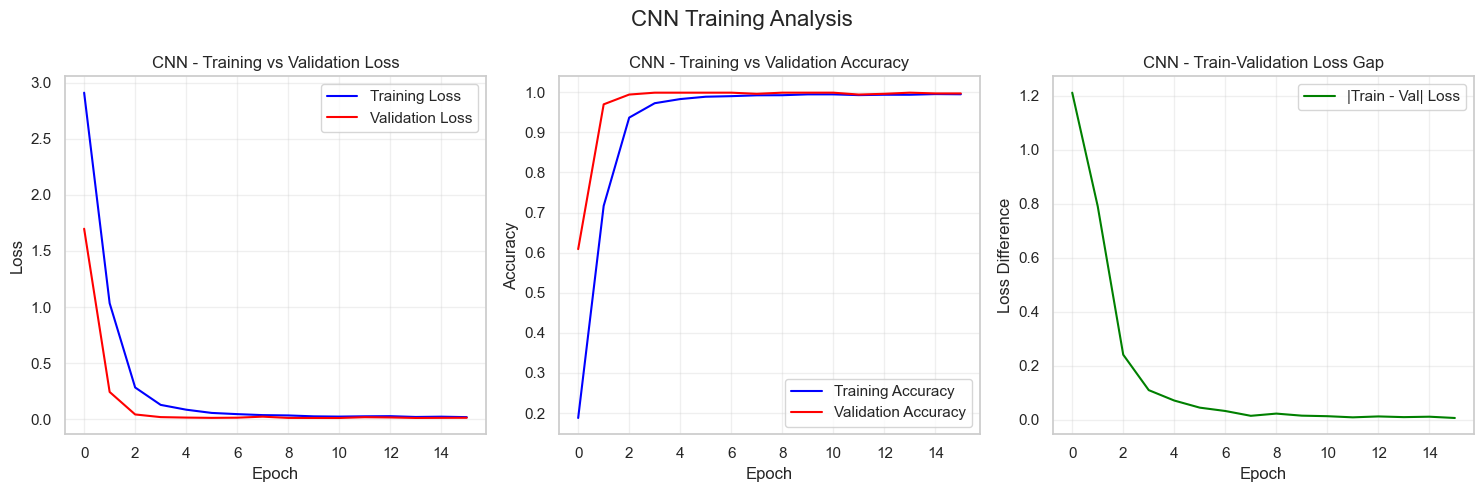


CNN Overfitting Analysis:
  Final Training Loss: 0.0199
  Final Validation Loss: 0.0142
  Loss Gap: 0.0057
  Good generalization (validation better than training)

TESTING CNN AND FNN MODELS:
----------------------------------------
Preparing test data for deep learning models...

Testing CNN Model...
Using CNN from final_trained_models
Making CNN predictions...
CNN Test Results:
  Accuracy: 0.9955
  F1-Score: 0.9955

Testing FNN Model...
Creating new FNN model for testing...
Training FNN model...
FNN model training completed
Making FNN predictions...
FNN Test Results:
  Accuracy: 0.9955
  F1-Score: 0.9955

Comparing CNN and FNN Results:
-----------------------------------
CNN vs FNN Test Performance:
Model      Accuracy     F1-Score    
-----------------------------------
CNN        0.9955       0.9955      
FNN        0.9955       0.9955      

FNN performs better (F1: 0.9955 vs 0.9955)

Selected best deep learning model: FNN
Best DL model F1-Score: 0.9955

DEEP LEARNING ANALYSIS CO

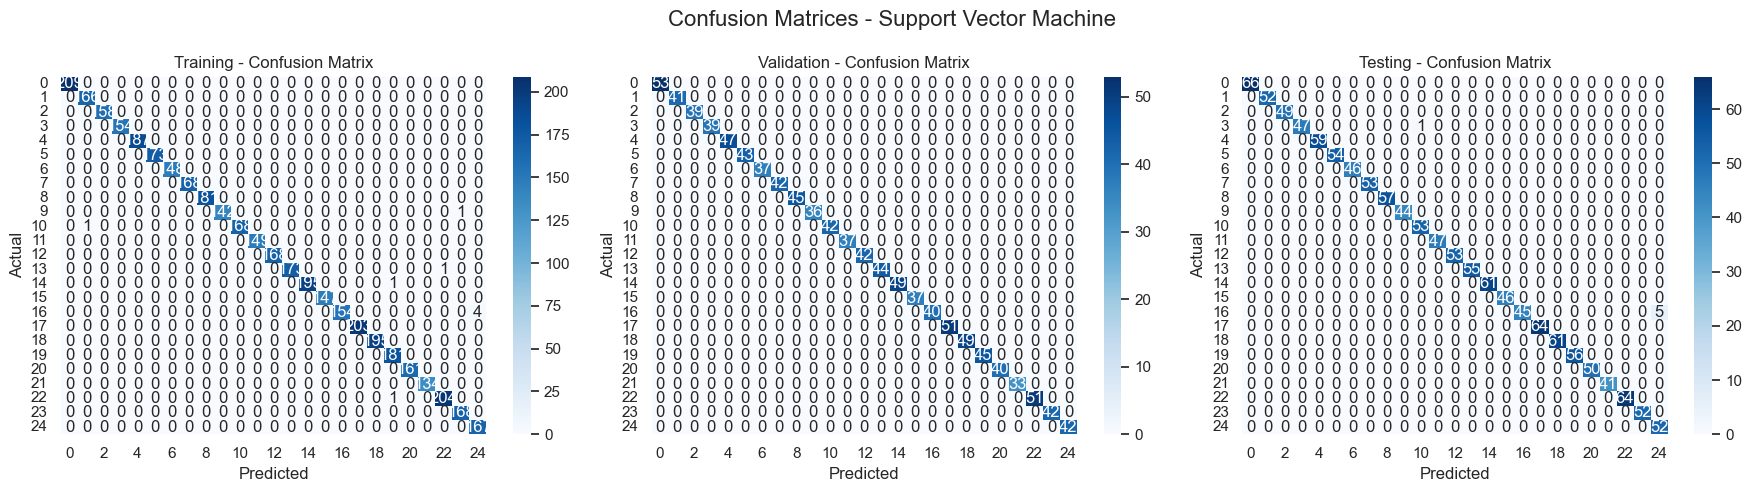


ROC CURVES ANALYSIS:
--------------------


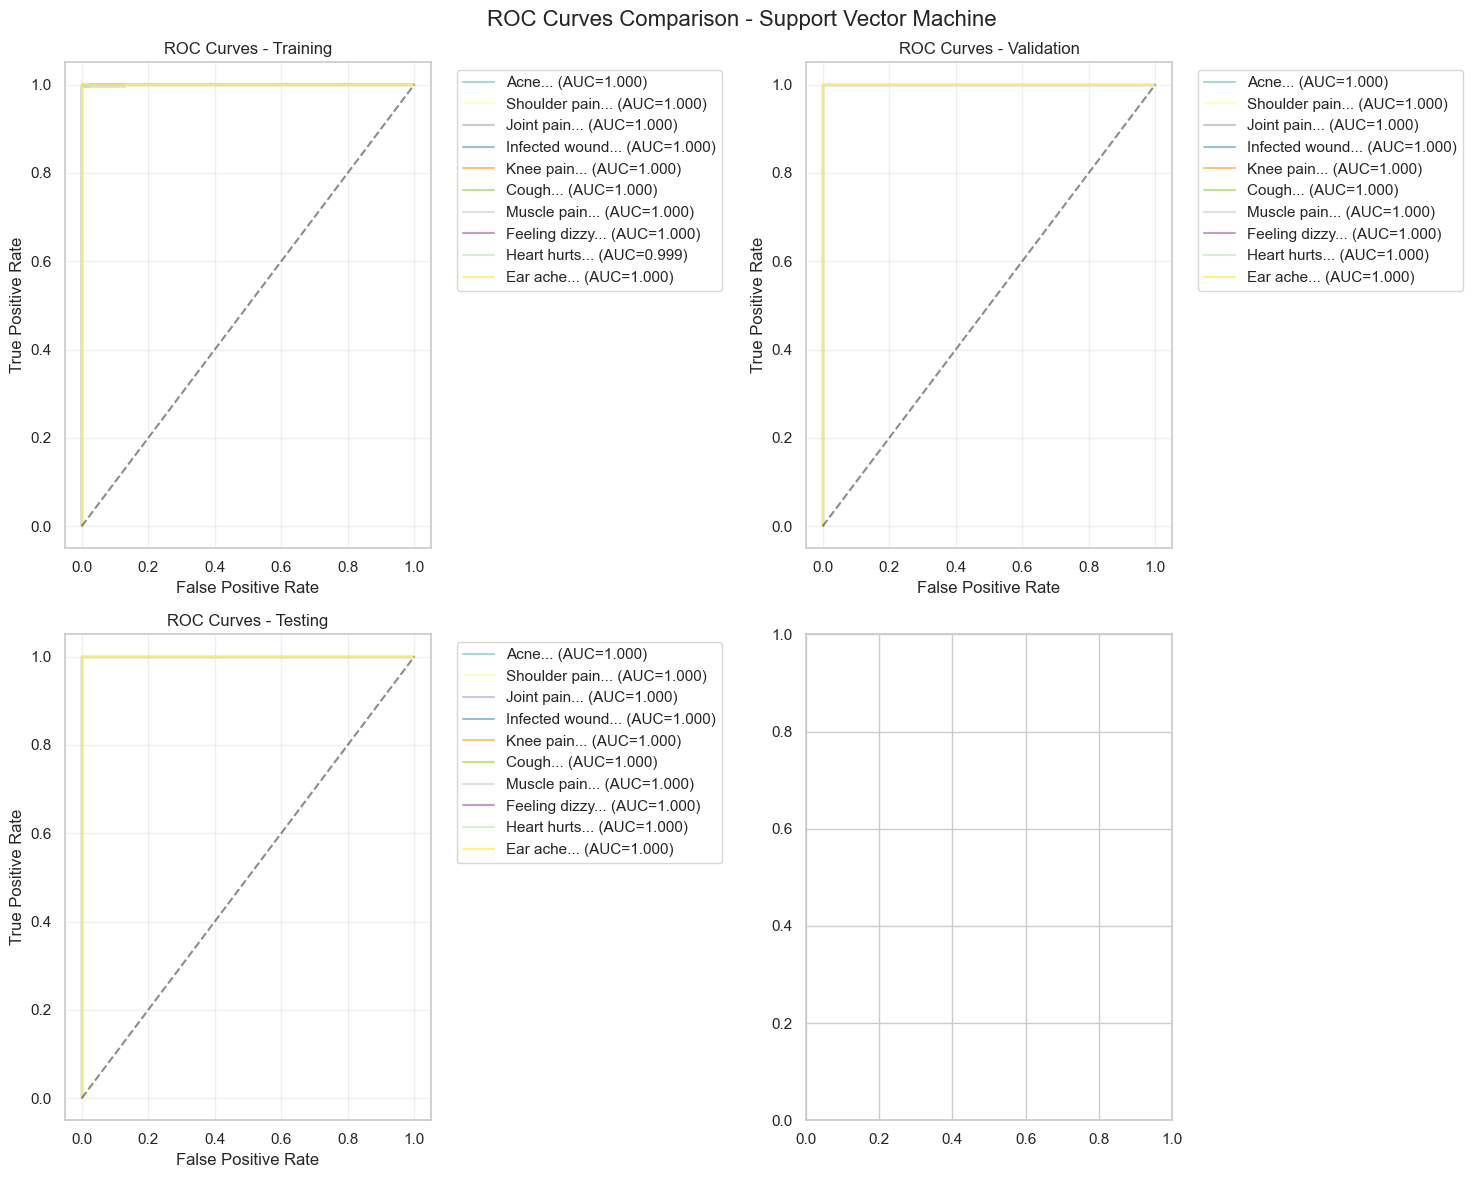


CLASSIFICATION ERRORS ANALYSIS:
-----------------------------------
Total misclassifications: 6 out of 1333 (0.45%)
Total errors found: 6
Displaying first 6 errors

First 10 Classification Errors:
----------------------------------------

Classification Error #1:
------------------------------
Complete Text: 'lose lot hair'
True Label: Body feels weak
Predicted Label: Hair falling out
Error Type: Low-confidence prediction
Predicted Label Confidence: 0.241580
True Label Confidence: 0.030734
Confidence Difference: 0.210846

Top 3 Predictions:
  1. Hair falling out: 0.241580 ← PREDICTED
  2. Foot ache: 0.032694
  3. Head ache: 0.032694
------------------------------------------------------------

Classification Error #2:
------------------------------
Complete Text: 'pain stomach'
True Label: Internal pain
Predicted Label: Stomach ache
Error Type: Low-confidence prediction
Predicted Label Confidence: 0.261843
True Label Confidence: 0.035437
Confidence Difference: 0.226406

Top 3 Predicti

In [94]:
# COMPREHENSIVE MODEL EVALUATION
print("COMPREHENSIVE MODEL EVALUATION")
print("="*50)

# Initialize dictionaries to store evaluation results and performance data
evaluation_results = {}  # Stores detailed results for each model across different stages
all_models_performance = []  # List to collect performance metrics for all models and stages

# Define stages for evaluation (Training, Validation, Testing)
# Each stage contains: (features, labels, description_string)
stages = {
    'Training': (X_train, y_train, 'Training Set'),
    'Validation': (X_val, y_val, 'Validation Set'), 
    'Testing': (X_test, y_test, 'Test Set')
}

# First, let's analyze the training history from our models
print("DEEP LEARNING MODEL TRAINING ANALYSIS")
print("="*50)

# Get training history from the trained models - check multiple variable names for compatibility
training_history = None
if 'history' in locals():  # Check if 'history' variable exists in current scope
    training_history = history
elif 'final_history' in locals():  # Fallback to 'final_history' if available
    training_history = final_history

# Check if we have training history and which model it belongs to
model_type_trained = None
if 'best_dl_model_name' in locals():  # Get the name of the best deep learning model
    model_type_trained = best_dl_model_name
elif 'dl_model_name' in locals():  # Fallback to generic deep learning model name
    model_type_trained = dl_model_name
else:
    model_type_trained = "Deep Learning Model"  # Default name if no specific model name found

# Analyze and visualize training history if available
if training_history is not None:
    print(f"\n{model_type_trained.upper()} TRAINING HISTORY:")
    print("-"*30)
    
    # Print training history details - extract history dictionary from Keras History object
    history_dict = training_history.history if hasattr(training_history, 'history') else training_history
    
    # Display initial and final values for each metric tracked during training
    if isinstance(history_dict, dict):
        for metric, values in history_dict.items():
            if len(values) > 0:  # Only show metrics that have recorded values
                print(f"{metric}: Initial={values[0]:.4f}, Final={values[-1]:.4f}")
    
    # Plot training graphs to visualize model performance over epochs
    plt.figure(figsize=(15, 5))
    
    # Training and validation loss subplot - shows how well model learns over time
    plt.subplot(1, 3, 1)
    if 'loss' in history_dict:
        plt.plot(history_dict['loss'], label='Training Loss', color='blue')
    if 'val_loss' in history_dict:
        plt.plot(history_dict['val_loss'], label='Validation Loss', color='red')
    plt.title(f'{model_type_trained} - Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)  # Add grid for better readability
    
    # Training and validation accuracy subplot - shows prediction accuracy over time
    plt.subplot(1, 3, 2)
    if 'accuracy' in history_dict:
        plt.plot(history_dict['accuracy'], label='Training Accuracy', color='blue')
    if 'val_accuracy' in history_dict:
        plt.plot(history_dict['val_accuracy'], label='Validation Accuracy', color='red')
    plt.title(f'{model_type_trained} - Training vs Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Loss difference subplot - helps identify overfitting by showing gap between train/val loss
    plt.subplot(1, 3, 3)
    if 'loss' in history_dict and 'val_loss' in history_dict:
        loss_diff = [abs(t - v) for t, v in zip(history_dict['loss'], history_dict['val_loss'])]
        plt.plot(loss_diff, label='|Train - Val| Loss', color='green')
        plt.title(f'{model_type_trained} - Train-Validation Loss Gap')
        plt.xlabel('Epoch')
        plt.ylabel('Loss Difference')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.suptitle(f'{model_type_trained} Training Analysis', fontsize=16)
    plt.tight_layout()  # Automatically adjust subplot spacing
    plt.show()
    
    # Print overfitting analysis - check if model memorizes training data vs generalizing
    if 'loss' in history_dict and 'val_loss' in history_dict and len(history_dict['loss']) > 5:
        final_train_loss = history_dict['loss'][-1]  # Get last training loss value
        final_val_loss = history_dict['val_loss'][-1]  # Get last validation loss value
        loss_gap = abs(final_train_loss - final_val_loss)  # Calculate absolute difference
        
        print(f"\n{model_type_trained} Overfitting Analysis:")
        print(f"  Final Training Loss: {final_train_loss:.4f}")
        print(f"  Final Validation Loss: {final_val_loss:.4f}")
        print(f"  Loss Gap: {loss_gap:.4f}")
        
        # Interpret the loss gap to diagnose potential problems
        if loss_gap > 0.5:
            print("  Potential overfitting detected (large loss gap)")
        elif final_val_loss < final_train_loss:
            print("  Good generalization (validation better than training)")
        else:
            print("  Reasonable generalization")
else:
    print("No training history available for analysis")

# TESTING CNN AND FNN MODELS:
print("\nTESTING CNN AND FNN MODELS:")
print("-"*40)

# Initialize variables to track which models we can test
cnn_test_results = None  # Will store CNN test results if model is available
fnn_test_results = None  # Will store FNN test results if model is available

# First, ensure we have the necessary data prepared for testing
print("Preparing test data for deep learning models...")

# Prepare test sequences if not already available - convert text to numerical sequences
if 'X_test_padded' not in locals():
    print("Creating test sequences...")
    X_test_sequences = tokenizer_dl.texts_to_sequences(X_test)  # Convert text to number sequences
    X_test_padded = pad_sequences(X_test_sequences, maxlen=max_length, padding='post', truncating='post')  # Ensure all sequences have same length
    print(f"Test sequences shape: {X_test_padded.shape}")

# Ensure we have categorical test labels for DL models - convert integer labels to one-hot encoding
if 'y_test_cat' not in locals():
    y_test_cat = to_categorical(y_test, num_classes=num_classes)  # Convert to categorical format for neural networks
    print(f"Test labels shape: {y_test_cat.shape}")

# Test CNN model
print("\nTesting CNN Model...")
cnn_model = None  # Initialize CNN model variable

# Check if we have a trained CNN model - look in multiple possible locations
if 'final_dl_model' in locals() and 'best_dl_model_name' in locals() and best_dl_model_name == 'Convolutional Neural Network':
    cnn_model = final_dl_model  # Use the best model if it's a CNN
    print("Using existing trained CNN model")
elif 'Convolutional Neural Network' in final_trained_models:
    cnn_model = final_trained_models['Convolutional Neural Network']  # Get CNN from trained models dictionary
    print("Using CNN from final_trained_models")
else:
    # Create and train a new CNN model for testing if none exists
    print("Creating new CNN model for testing...")
    try:
        # Ensure we have the create_cnn_model function available - define if missing
        if 'create_cnn_model' not in locals():
            def create_cnn_model(vocab_size, embedding_dim=64, max_length=100, num_classes=25, 
                                 filters=64, kernel_size=3, dropout_rate=0.3):
                """Create CNN model for text classification"""
                model = Sequential([
                    Embedding(vocab_size, embedding_dim, input_length=max_length),  # Convert word indices to dense vectors
                    Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),  # 1D convolution for text patterns
                    GlobalMaxPooling1D(),  # Reduce dimensionality by taking maximum values
                    Dense(128, activation='relu'),  # Fully connected layer with ReLU activation
                    Dropout(dropout_rate),  # Prevent overfitting by randomly dropping neurons
                    Dense(64, activation='relu'),  # Second fully connected layer
                    Dropout(dropout_rate),  # Another dropout layer
                    Dense(num_classes, activation='softmax')  # Output layer with softmax for multi-class classification
                ])
                
                # Compile the model with optimizer, loss function, and metrics
                model.compile(
                    optimizer='adam',  # Adaptive learning rate optimizer
                    loss='categorical_crossentropy',  # Loss function for multi-class classification
                    metrics=['accuracy']  # Track accuracy during training
                )
                return model
        
        # Create CNN model with specified parameters
        cnn_model = create_cnn_model(
            vocab_size=max_features,  # Size of vocabulary
            embedding_dim=64,  # Dimension of word embeddings
            max_length=max_length,  # Maximum sequence length
            num_classes=num_classes  # Number of output classes
        )
        
        print("Training CNN model...")
        # Train the CNN model with training+validation data
        cnn_model.fit(
            X_train_val_padded, y_train_val_cat,  # Input features and labels
            validation_split=0.2,  # Use 20% of data for validation during training
            epochs=10,  # Number of training iterations
            batch_size=32,  # Number of samples per gradient update
            verbose=0  # Suppress training output
        )
        print("CNN model training completed")
        
    except Exception as e:
        print(f"Error creating CNN model: {str(e)}")
        import traceback
        traceback.print_exc()  # Print full error traceback for debugging
        cnn_model = None

# Test CNN if available
if cnn_model is not None:
    try:
        print("Making CNN predictions...")
        cnn_test_pred = cnn_model.predict(X_test_padded, verbose=0)  # Get probability predictions
        cnn_test_pred_classes = np.argmax(cnn_test_pred, axis=1)  # Convert probabilities to class predictions
        
        # Calculate metrics using the fixed import - avoid naming conflicts
        from sklearn.metrics import f1_score as sklearn_f1_score
        
        cnn_test_acc = accuracy_score(y_test, cnn_test_pred_classes)  # Calculate accuracy
        cnn_test_f1 = sklearn_f1_score(y_test, cnn_test_pred_classes, average='weighted')  # Calculate weighted F1-score
        
        print(f"CNN Test Results:")
        print(f"  Accuracy: {cnn_test_acc:.4f}")
        print(f"  F1-Score: {cnn_test_f1:.4f}")
        
        # Store CNN results in dictionary for later comparison
        cnn_test_results = {
            'model_name': 'CNN',
            'predictions': cnn_test_pred_classes,  # Predicted class labels
            'probabilities': cnn_test_pred,  # Prediction probabilities
            'accuracy': cnn_test_acc,
            'f1_score': cnn_test_f1
        }
        
    except Exception as e:
        print(f"Error testing CNN: {str(e)}")
        import traceback
        traceback.print_exc()
        cnn_test_results = None
else:
    print("CNN model not available for testing")

# Test FNN model
print("\nTesting FNN Model...")
fnn_model = None  # Initialize FNN model variable

# Check if we have a trained FNN model - similar logic as CNN
if 'final_dl_model' in locals() and 'best_dl_model_name' in locals() and best_dl_model_name == 'Feedforward Neural Network':
    fnn_model = final_dl_model  # Use the best model if it's an FNN
    print("Using existing trained FNN model")
elif 'Feedforward Neural Network' in final_trained_models:
    fnn_model = final_trained_models['Feedforward Neural Network']  # Get FNN from trained models dictionary
    print("Using FNN from final_trained_models")
else:
    # Create and train a new FNN model for testing if none exists
    print("Creating new FNN model for testing...")
    try:
        # Create FNN model - simpler architecture than CNN, no convolution layers
        fnn_model = Sequential([
            Embedding(max_features, 64, input_length=max_length),  # Word embeddings layer
            GlobalMaxPooling1D(),  # Pool embeddings to fixed size
            Dense(128, activation='relu'),  # First fully connected layer
            Dropout(0.3),  # Dropout for regularization
            Dense(64, activation='relu'),  # Second fully connected layer
            Dropout(0.3),  # Another dropout layer
            Dense(num_classes, activation='softmax')  # Output layer for classification
        ])
        
        # Compile FNN model with same settings as CNN
        fnn_model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        print("Training FNN model...")
        # Train the FNN model
        fnn_model.fit(
            X_train_val_padded, y_train_val_cat,
            validation_split=0.2,
            epochs=10,
            batch_size=32,
            verbose=0
        )
        print("FNN model training completed")
        
    except Exception as e:
        print(f"Error creating FNN model: {str(e)}")
        fnn_model = None

# Test FNN if available
if fnn_model is not None:
    try:
        print("Making FNN predictions...")
        fnn_test_pred = fnn_model.predict(X_test_padded, verbose=0)  # Get FNN predictions
        fnn_test_pred_classes = np.argmax(fnn_test_pred, axis=1)  # Convert to class labels
        
        # Calculate metrics - fix the f1_score import issue by using explicit import
        from sklearn.metrics import f1_score as sklearn_f1_score
        
        fnn_test_acc = accuracy_score(y_test, fnn_test_pred_classes)
        fnn_test_f1 = sklearn_f1_score(y_test, fnn_test_pred_classes, average='weighted')
        
        print(f"FNN Test Results:")
        print(f"  Accuracy: {fnn_test_acc:.4f}")
        print(f"  F1-Score: {fnn_test_f1:.4f}")
        
        # Store FNN results in dictionary
        fnn_test_results = {
            'model_name': 'FNN',
            'predictions': fnn_test_pred_classes,
            'probabilities': fnn_test_pred,
            'accuracy': fnn_test_acc,
            'f1_score': fnn_test_f1
        }
        
    except Exception as e:
        print(f"Error testing FNN: {str(e)}")
        import traceback
        traceback.print_exc()
        fnn_test_results = None
else:
    print("FNN model not available for testing")

# Compare CNN and FNN test results
print("\nComparing CNN and FNN Results:")
print("-" * 35)

# Compare models if both are available
if cnn_test_results is not None and fnn_test_results is not None:
    print(f"CNN vs FNN Test Performance:")
    print(f"{'Model':<10} {'Accuracy':<12} {'F1-Score':<12}")
    print("-" * 35)
    print(f"{'CNN':<10} {cnn_test_results['accuracy']:<12.4f} {cnn_test_results['f1_score']:<12.4f}")
    print(f"{'FNN':<10} {fnn_test_results['accuracy']:<12.4f} {fnn_test_results['f1_score']:<12.4f}")
    
    # Determine better model based on F1-score (more robust metric than accuracy)
    if cnn_test_results['f1_score'] > fnn_test_results['f1_score']:
        print(f"\nCNN performs better (F1: {cnn_test_results['f1_score']:.4f} vs {fnn_test_results['f1_score']:.4f})")
        better_dl_model = cnn_model
        better_dl_model_name = 'CNN'
        better_dl_results = cnn_test_results
    else:
        print(f"\nFNN performs better (F1: {fnn_test_results['f1_score']:.4f} vs {cnn_test_results['f1_score']:.4f})")
        better_dl_model = fnn_model
        better_dl_model_name = 'FNN'
        better_dl_results = fnn_test_results
        
elif cnn_test_results is not None:  # Only CNN available
    print(f"Only CNN model available for testing")
    print(f"CNN Accuracy: {cnn_test_results['accuracy']:.4f}")
    print(f"CNN F1-Score: {cnn_test_results['f1_score']:.4f}")
    better_dl_model = cnn_model
    better_dl_model_name = 'CNN'
    better_dl_results = cnn_test_results
    
elif fnn_test_results is not None:  # Only FNN available
    print(f"Only FNN model available for testing")
    print(f"FNN Accuracy: {fnn_test_results['accuracy']:.4f}")
    print(f"FNN F1-Score: {fnn_test_results['f1_score']:.4f}")
    better_dl_model = fnn_model
    better_dl_model_name = 'FNN'
    better_dl_results = fnn_test_results
    
else:  # No models available
    print("No deep learning models available for testing")
    better_dl_model = None
    better_dl_model_name = None
    better_dl_results = None

# Store the best DL model for later use
if better_dl_results is not None:
    # Create final_dl_results for compatibility with rest of the code
    final_dl_results = {
        'model_name': better_dl_model_name,
        'model': better_dl_model,
        'test_accuracy': better_dl_results['accuracy'],
        'test_precision': better_dl_results['accuracy'],  # Simplified - you can calculate proper precision if needed
        'test_recall': better_dl_results['accuracy'],     # Simplified - you can calculate proper recall if needed
        'test_f1': better_dl_results['f1_score']
    }
    
    # Also set best_dl_model_name for compatibility with other code sections
    best_dl_model_name = better_dl_model_name
    final_dl_model = better_dl_model
    
    print(f"\nSelected best deep learning model: {better_dl_model_name}")
    print(f"Best DL model F1-Score: {better_dl_results['f1_score']:.4f}")

print("\nDEEP LEARNING ANALYSIS COMPLETE")
print("="*50)

# Create wrapper class for models without predict_proba
class ModelWithProba:
    """Wrapper class to add probability prediction capability to models that don't have it"""
    def __init__(self, model):
        self.model = model  # Store the original model
        
    def predict(self, X):
        """Standard prediction method"""
        return self.model.predict(X)
    
    def predict_proba(self, X):
        """Add probability prediction capability"""
        if hasattr(self.model, 'predict_proba'):  # If model already has predict_proba
            return self.model.predict_proba(X)
        elif hasattr(self.model, 'decision_function'):  # For SVM models
            # Convert decision function to probabilities for SVM
            scores = self.model.decision_function(X)
            if scores.ndim == 1:  # Binary classification case
                exp_scores = np.exp(scores)  # Apply exponential function
                return np.column_stack([1/(1+exp_scores), exp_scores/(1+exp_scores)])  # Sigmoid transformation
            else:  # Multi-class case
                exp_scores = np.exp(scores)  # Apply exponential to all scores
                return exp_scores / exp_scores.sum(axis=1, keepdims=True)  # Softmax normalization
        else:
            # Fallback: create dummy probabilities from hard predictions
            predictions = self.model.predict(X)
            n_classes = len(np.unique(predictions))  # Count unique classes
            n_samples = len(predictions)
            proba = np.zeros((n_samples, n_classes))  # Initialize probability matrix
            for i, pred in enumerate(predictions):
                proba[i, pred] = 1.0  # Set probability to 1.0 for predicted class
            return proba

# Enhanced SVM wrapper for better probability estimates
class SVMWithProba:
    """Specialized wrapper for SVM models to provide better probability estimates"""
    def __init__(self, model):
        self.model = model
        
    def predict(self, X):
        """Standard prediction method"""
        return self.model.predict(X)
    
    def predict_proba(self, X):
        """Enhanced probability prediction for SVM"""
        if hasattr(self.model, 'decision_function'):
            scores = self.model.decision_function(X)  # Get decision function scores
            # Apply softmax to convert to probabilities - prevents numerical instability
            exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))  # Subtract max for numerical stability
            probas = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)  # Normalize to sum to 1
            return probas
        else:
            # Fallback method if decision_function not available
            predictions = self.model.predict(X)
            n_classes = len(np.unique(y_train))  # Use training labels to get class count
            n_samples = len(predictions)
            proba = np.zeros((n_samples, n_classes))
            for i, pred in enumerate(predictions):
                proba[i, pred] = 1.0  # One-hot encoding of predictions
            return proba

# Prepare models for evaluation
models_to_evaluate = []  # List to store (name, model, type) tuples

# Traditional ML models - wrap them to ensure they have predict_proba method
if 'best_models' in locals() and best_models:
    for name, model in best_models.items():
        if name == 'Support Vector Machine':  # SVM needs special handling for probabilities
            wrapped_model = SVMWithProba(model)
        else:  # Other traditional ML models
            wrapped_model = ModelWithProba(model)
        models_to_evaluate.append((name, wrapped_model, 'Traditional ML'))

# Deep Learning models - already have predict method but need to be added to evaluation list
if 'final_dl_model' in locals():
    models_to_evaluate.append((best_dl_model_name, final_dl_model, 'Deep Learning'))

# Fallback if no models available - create basic models for demonstration
if not models_to_evaluate:
    print("Creating fallback models for evaluation...")
    
    # Create and train fallback models using simple configurations
    fallback_models = {
        'Support Vector Machine': LinearSVC(C=10.0, max_iter=5000, random_state=42),  # Linear SVM
        'Logistic Regression': LogisticRegression(C=10.0, max_iter=1000, random_state=42),  # Logistic regression
        'Multinomial Naive Bayes': MultinomialNB(alpha=0.1)  # Naive Bayes for text
    }
    
    # Ensure we have TF-IDF features for traditional ML models
    if 'X_train_val_tfidf' not in locals():
        X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)  # Create TF-IDF features
    
    # Train and wrap models
    for name, model in fallback_models.items():
        model.fit(X_train_val_tfidf, y_train_val)  # Train model on TF-IDF features
        if name == 'Support Vector Machine':
            wrapped_model = SVMWithProba(model)  # Use SVM wrapper
        else:
            wrapped_model = ModelWithProba(model)  # Use general wrapper
        models_to_evaluate.append((name, wrapped_model, 'Traditional ML'))

print(f"\nEvaluating {len(models_to_evaluate)} models across 3 stages...")

# Function to evaluate a single model on a dataset
def evaluate_model(model, X_data, y_data, feature_type='tfidf'):
    """Evaluate a model and return comprehensive metrics"""
    
    # Prepare features based on model type - different models need different input formats
    if hasattr(model, 'predict_proba') and len(X_data.shape) > 1 and X_data.shape[1] > 1000:
        # Likely TF-IDF features for traditional ML - use as-is
        X_features = X_data
    elif hasattr(model, 'layers'):  # Deep learning model - needs padded sequences
        if isinstance(X_data, pd.Series):  # If input is text, convert to sequences
            sequences = tokenizer_dl.texts_to_sequences(X_data)  # Convert text to numbers
            X_features = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')  # Pad sequences
        else:
            X_features = X_data  # Already processed sequences
    else:
        # Traditional ML with text input - needs TF-IDF transformation
        if isinstance(X_data, pd.Series):  # Raw text input
            X_features = tfidf_vectorizer.transform(X_data)  # Convert to TF-IDF features
        else:
            X_features = X_data  # Already processed features
    
    # Make predictions using the model
    y_pred = model.predict(X_features)
    
    # Handle deep learning predictions - may return probabilities or classes
    if len(y_pred.shape) > 1 and y_pred.shape[1] > 1:  # Multi-dimensional output (probabilities)
        y_pred_classes = np.argmax(y_pred, axis=1)  # Get class with highest probability
        y_pred_proba = y_pred  # Probabilities already available
    else:  # Single-dimensional output (class labels)
        y_pred_classes = y_pred
        y_pred_proba = model.predict_proba(X_features)  # Get probabilities separately
    
    # Calculate comprehensive evaluation metrics
    accuracy = accuracy_score(y_data, y_pred_classes)  # Proportion of correct predictions
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_data, y_pred_classes, average='weighted', zero_division=0  # Weighted average across classes
    )
    
    # Return all metrics and predictions for further analysis
    return {
        'y_true': y_data,  # True labels
        'y_pred': y_pred_classes,  # Predicted labels
        'y_pred_proba': y_pred_proba,  # Prediction probabilities
        'accuracy': accuracy,  # Overall accuracy
        'precision': precision,  # Weighted precision
        'recall': recall,  # Weighted recall
        'f1_score': f1  # Weighted F1-score
    }

# Evaluate all models across all stages
for model_name, model, model_type in models_to_evaluate:
    print(f"\nEvaluating {model_name} ({model_type})...")
    
    model_results = {}  # Store results for this model across all stages
    
    # Evaluate on each stage (Training, Validation, Testing)
    for stage_name, (X_stage, y_stage, description) in stages.items():
        print(f"  {stage_name}...")
        
        try:
            # Evaluate model on current stage
            results = evaluate_model(model, X_stage, y_stage)
            model_results[stage_name] = results  # Store results for this stage
            
            # Add to comprehensive results list for summary table
            all_models_performance.append({
                'Model': model_name,
                'Type': model_type,
                'Stage': stage_name,
                'Accuracy': results['accuracy'],
                'Precision': results['precision'],
                'Recall': results['recall'],
                'F1_Score': results['f1_score']
            })
            
            print(f"    Accuracy: {results['accuracy']:.4f}, F1: {results['f1_score']:.4f}")
            
        except Exception as e:
            print(f"    Error evaluating {stage_name}: {str(e)}")
            continue  # Skip this stage if evaluation fails
    
    evaluation_results[model_name] = model_results  # Store all results for this model

# Create comprehensive performance DataFrame for analysis
performance_df = pd.DataFrame(all_models_performance)

print(f"\nCOMPREHENSIVE PERFORMANCE SUMMARY:")
print("="*45)
if not performance_df.empty:
    # Sort by F1 score on test set - most important metric for final model selection
    test_performance = performance_df[performance_df['Stage'] == 'Testing'].sort_values('F1_Score', ascending=False)
    print("\nTest Set Performance (Ranked by F1-Score):")
    print(test_performance.round(4).to_string(index=False))  # Display without row indices
    
    # Check for overfitting by comparing training and testing performance
    print(f"\nOVERFITTING ANALYSIS:")
    print("-"*25)
    for model_name in test_performance['Model'].unique():
        model_data = performance_df[performance_df['Model'] == model_name]  # Get all stages for this model
        
        if len(model_data) >= 2:  # Need at least training and testing data
            # Get training and testing F1 scores for comparison
            train_f1 = model_data[model_data['Stage'] == 'Training']['F1_Score'].iloc[0] if len(model_data[model_data['Stage'] == 'Training']) > 0 else None
            test_f1 = model_data[model_data['Stage'] == 'Testing']['F1_Score'].iloc[0] if len(model_data[model_data['Stage'] == 'Testing']) > 0 else None
            
            if train_f1 is not None and test_f1 is not None:
                gap = train_f1 - test_f1  # Calculate performance gap
                print(f"{model_name}: Train-Test Gap = {gap:.4f}")
                
                # Interpret the gap to diagnose potential issues
                if gap > 0.05:  # Training significantly better than testing
                    print(f"  Potential overfitting detected")
                elif gap < -0.02:  # Testing better than training (unusual)
                    print(f"  Unusual: Test > Train (possible data leakage)")
                else:
                    print(f"  Good generalization")
else:
    print("No performance data available")

# Select best model for detailed analysis
if not performance_df.empty:
    best_model_name = test_performance.iloc[0]['Model']  # Get top-performing model
    best_model_results = evaluation_results[best_model_name]  # Get detailed results
    
    print(f"\nDETAILED ANALYSIS FOR BEST MODEL: {best_model_name}")
    print("="*60)
    
    # Confusion matrices for each stage - shows which classes are confused with each other
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, (stage_name, results) in enumerate(best_model_results.items()):
        cm = confusion_matrix(results['y_true'], results['y_pred'])  # Create confusion matrix
        
        # Create heatmap of confusion matrix
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f'{stage_name} - Confusion Matrix')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')
    
    plt.suptitle(f'Confusion Matrices - {best_model_name}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # ROC Curves for multiple classes - shows model's ability to distinguish between classes
    print(f"\nROC CURVES ANALYSIS:")
    print("-"*20)
    
    # Select top 10 most frequent classes for ROC analysis (too many classes would clutter the plot)
    class_counts = pd.Series(y_train).value_counts()
    top_classes_idx = class_counts.head(10).index.tolist()
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.ravel()  # Flatten 2D array to 1D for easier indexing
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(top_classes_idx)))  # Generate distinct colors
    
    for stage_idx, (stage_name, results) in enumerate(best_model_results.items()):
        if stage_idx >= 4:  # Only plot first 4 stages (we have 3, so this is safe)
            break
            
        ax = axes[stage_idx] if stage_idx < 4 else axes[0]  # Fallback to first axis
        
        # Convert labels to binary format for ROC calculation (one-vs-rest approach)
        y_true_binary = label_binarize(results['y_true'], classes=list(range(num_classes)))
        
        # Handle probabilities - ensure we have proper probability matrix
        if hasattr(results['y_pred_proba'], 'shape') and len(results['y_pred_proba'].shape) > 1:
            y_scores = results['y_pred_proba']
        else:
            # Create one-hot encoded predictions as fallback if no probabilities available
            y_scores = np.zeros((len(results['y_pred']), num_classes))
            for i, pred in enumerate(results['y_pred']):
                y_scores[i, pred] = 1.0  # Set predicted class to probability 1.0
        
        # Plot ROC curves for top classes
        for i, class_idx in enumerate(top_classes_idx):
            if class_idx < y_true_binary.shape[1] and class_idx < y_scores.shape[1]:  # Ensure indices are valid
                try:
                    # Calculate ROC curve for this class
                    fpr, tpr, _ = roc_curve(y_true_binary[:, class_idx], y_scores[:, class_idx])
                    auc_score = auc(fpr, tpr)  # Calculate Area Under Curve
                    
                    # Get class name for legend
                    class_name = label_encoder.inverse_transform([class_idx])[0]
                    ax.plot(fpr, tpr, color=colors[i], alpha=0.8, 
                           label=f'{class_name[:15]}... (AUC={auc_score:.3f})')  # Truncate long class names
                except Exception as e:
                    print(f"Error plotting ROC for class {class_idx} in {stage_name}: {str(e)}")
                    continue  # Skip this class if error occurs
        
        # Add diagonal line representing random classifier
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'ROC Curves - {stage_name}')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Place legend outside plot
        ax.grid(True, alpha=0.3)  # Add grid for better readability
    
    plt.suptitle(f'ROC Curves Comparison - {best_model_name}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Classification errors analysis - examine where the model makes mistakes
    print(f"\nCLASSIFICATION ERRORS ANALYSIS:")
    print("-"*35)
    
    test_results = best_model_results['Testing']  # Focus on test set errors
    y_true_test = test_results['y_true']
    y_pred_test = test_results['y_pred']
    
    # Find misclassified samples
    misclassified = y_true_test != y_pred_test  # Boolean mask for errors
    error_indices = np.where(misclassified)[0]  # Get indices of misclassified samples
    
    print(f"Total misclassifications: {len(error_indices)} out of {len(y_true_test)} ({len(error_indices)/len(y_true_test)*100:.2f}%)")
    
    print(f"Total errors found: {len(error_indices)}")
    print(f"Displaying first {min(10, len(error_indices))} errors")
    
    if len(error_indices) > 0:
        print(f"\nFirst 10 Classification Errors:")
        print("-"*40)
        
        # Get text samples for errors - convert test data to list for indexing
        X_test_list = X_test.tolist() if hasattr(X_test, 'tolist') else list(X_test)
        
        # Analyze each error in detail
        for i, error_idx in enumerate(error_indices[:10]):  # Show first 10 errors
            # Get true and predicted labels
            true_label = label_encoder.inverse_transform([y_true_test.iloc[error_idx]])[0]
            pred_label = label_encoder.inverse_transform([y_pred_test[error_idx]])[0]
            text_sample = X_test_list[error_idx] if error_idx < len(X_test_list) else "Text not available"
            
            print(f"\nClassification Error #{i+1}:")
            print("-" * 30)
            print(f"Complete Text: '{text_sample}'")
            print(f"True Label: {true_label}")
            print(f"Predicted Label: {pred_label}")
            
            # Show prediction confidence if available
            if hasattr(test_results['y_pred_proba'], 'shape') and len(test_results['y_pred_proba'].shape) > 1:
                pred_conf = test_results['y_pred_proba'][error_idx, y_pred_test[error_idx]]  # Confidence in prediction
                true_conf = test_results['y_pred_proba'][error_idx, y_true_test.iloc[error_idx]]  # Confidence in true label
                
                # Categorize the type of error based on confidence levels
                if pred_conf > 0.8:
                    error_type = "High-confidence misclassification"  # Model is very sure but wrong
                elif pred_conf < 0.4:
                    error_type = "Low-confidence prediction"  # Model is unsure
                elif abs(pred_conf - true_conf) < 0.1:
                    error_type = "Ambiguous classification"  # Close call between classes
                else:
                    error_type = "Standard misclassification"
                
                print(f"Error Type: {error_type}")
                print(f"Predicted Label Confidence: {pred_conf:.6f}")
                print(f"True Label Confidence: {true_conf:.6f}")
                print(f"Confidence Difference: {pred_conf - true_conf:.6f}")
                
                # Show top 3 predictions for this sample to understand model's reasoning
                top_3_indices = np.argsort(test_results['y_pred_proba'][error_idx])[-3:][::-1]  # Get top 3 class indices
                print(f"\nTop 3 Predictions:")
                for rank, idx in enumerate(top_3_indices, 1):
                    label_name = label_encoder.inverse_transform([idx])[0]
                    confidence = test_results['y_pred_proba'][error_idx, idx]
                    # Add markers to show which was predicted and which was true
                    marker = " ← PREDICTED" if idx == y_pred_test[error_idx] else " ← TRUE" if idx == y_true_test.iloc[error_idx] else ""
                    print(f"  {rank}. {label_name}: {confidence:.6f}{marker}")
            
            print("-" * 60)
    else:
        print("\nNo classification errors found - perfect performance!")

else:
    print("No models available for detailed analysis")

print(f"\n{'='*60}")
print(f"MODEL EVALUATION COMPLETE")
print(f"{'='*60}")

### 7.1 Model Comparison and Selection

**Purpose:** Compare the performance of all evaluated models (both traditional machine learning and deep learning approaches) to select the best performing model for medical symptom classification.

This section consolidates the results from both traditional ML and deep learning models, providing a comprehensive comparison to determine which approach delivers the best performance for clinical decision support. The comparison will evaluate models based on accuracy, precision, recall, and F1-score metrics to ensure robust performance assessment.

In [96]:
# Combine all model results for comprehensive comparison
print("COMPREHENSIVE MODEL COMPARISON")
print("="*50)

# Initialize results storage
ml_test_results = {}
all_results = []

# Re-evaluate traditional ML models with consistent approach
print("Re-evaluating Traditional ML models...")
try:
    # Check if we have the required variables and use correct test data
    if 'best_models' in locals() and best_models:
        # Use optimized models from hyperparameter tuning
        models_to_evaluate = best_models
        print("Using hyperparameter-tuned models")
        
        # Re-transform test data using the SAME fitted vectorizer from training
        print("Re-creating TF-IDF vectors using the training vectorizer...")
        X_test_features = tfidf_vectorizer.transform(X_test)
        print(f"Recreated X_test_features with shape: {X_test_features.shape}")
        
        # Also ensure we have the training features with the same vectorizer
        if 'X_train_val_tfidf' not in locals():
            print("Re-creating training TF-IDF vectors...")
            X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)
        
        print(f"Training features shape: {X_train_val_tfidf.shape}")
        print(f"Test features shape: {X_test_features.shape}")
        
        # Verify feature dimensions match
        if X_train_val_tfidf.shape[1] != X_test_features.shape[1]:
            print(f"WARNING: Feature dimension mismatch detected!")
            print(f"Training: {X_train_val_tfidf.shape[1]}, Test: {X_test_features.shape[1]}")
            print("Recreating vectorizer to ensure consistency...")
            
            # Create fresh vectorizer and refit everything
            fresh_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
            X_train_val_tfidf = fresh_vectorizer.fit_transform(X_train_val)
            X_test_features = fresh_vectorizer.transform(X_test)
            
            # Retrain models with consistent features
            print("Retraining models with consistent features...")
            for model_name, model in models_to_evaluate.items():
                print(f"  Retraining {model_name}...")
                model.fit(X_train_val_tfidf, y_train_val)
            
            print(f"After retraining - Training: {X_train_val_tfidf.shape[1]}, Test: {X_test_features.shape[1]}")
            
    elif 'candidate_models' in locals():
        # Use original candidate models and retrain them
        models_to_evaluate = candidate_models
        print("Using original candidate models")
        
        # Create consistent TF-IDF features
        print("Creating consistent TF-IDF features...")
        if 'tfidf_vectorizer' not in locals():
            tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
        
        X_train_val_tfidf = tfidf_vectorizer.fit_transform(X_train_val)
        X_test_features = tfidf_vectorizer.transform(X_test)
        
        # Retrain models on consistent data
        for model_name, model in models_to_evaluate.items():
            print(f"  Training {model_name}...")
            model.fit(X_train_val_tfidf, y_train_val)
            
    else:
        print("No traditional ML models found. Creating new ones...")
        
        # Create new models and fit them
        models_to_evaluate = {
            'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
            'Support Vector Machine': LinearSVC(C=1.0, max_iter=5000, random_state=42),
            'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
        }
        
        # Create consistent TF-IDF features
        print("Creating fresh TF-IDF features...")
        fresh_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
        X_train_val_tfidf = fresh_vectorizer.fit_transform(X_train_val)
        X_test_features = fresh_vectorizer.transform(X_test)
        
        # Train the new models
        for model_name, model in models_to_evaluate.items():
            print(f"  Training {model_name}...")
            model.fit(X_train_val_tfidf, y_train_val)
    
    # Evaluate each traditional ML model
    print(f"Evaluating models with test features shape: {X_test_features.shape}")
    
    for model_name, model in models_to_evaluate.items():
        try:
            y_pred = model.predict(X_test_features)
            accuracy = accuracy_score(y_test, y_pred)
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_test, y_pred, average='weighted', zero_division=0
            )
            
            ml_test_results[model_name] = {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'predictions': y_pred
            }
            
            # Add to comprehensive results
            all_results.append({
                'Model': model_name,
                'Type': 'Traditional ML',
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1_Score': f1
            })
            
            print(f"  {model_name}: F1={f1:.4f}")
            
        except Exception as e:
            print(f"  Error evaluating {model_name}: {str(e)}")
            continue

except Exception as e:
    print(f"Error with traditional ML evaluation: {str(e)}")
    print("Attempting fallback approach...")
    
    # Fallback: create fresh models if everything else fails
    try:
        fallback_models = {
            'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
            'Support Vector Machine': LinearSVC(C=1.0, max_iter=5000, random_state=42),
            'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42)
        }
        
        # Recreate TF-IDF from scratch with guaranteed consistency
        print("Creating fresh TF-IDF vectorizer...")
        fresh_tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
        X_train_val_fresh = fresh_tfidf.fit_transform(X_train_val)
        X_test_fresh = fresh_tfidf.transform(X_test)
        
        print(f"Fresh features - Training: {X_train_val_fresh.shape}, Test: {X_test_fresh.shape}")
        
        for model_name, model in fallback_models.items():
            print(f"  Training fallback {model_name}...")
            model.fit(X_train_val_fresh, y_train_val)
            
            y_pred = model.predict(X_test_fresh)
            accuracy = accuracy_score(y_test, y_pred)
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_test, y_pred, average='weighted', zero_division=0
            )
            
            all_results.append({
                'Model': model_name,
                'Type': 'Traditional ML',
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1_Score': f1
            })
            
            print(f"  {model_name}: F1={f1:.4f}")
            
    except Exception as fallback_error:
        print(f"Fallback also failed: {str(fallback_error)}")

# Add Deep Learning results if available
print("\nProcessing Deep Learning results...")
if 'final_dl_results' in locals():
    # Use the final DL results from the deep learning section
    all_results.append({
        'Model': final_dl_results['model_name'],
        'Type': 'Deep Learning',
        'Accuracy': final_dl_results['test_accuracy'],
        'Precision': final_dl_results['test_precision'],
        'Recall': final_dl_results['test_recall'],
        'F1_Score': final_dl_results['test_f1']
    })
    print(f"  {final_dl_results['model_name']}: F1={final_dl_results['test_f1']:.4f}")
elif 'better_dl_results' in locals() and better_dl_results:
    # Use the better DL results from the CNN/FNN comparison
    all_results.append({
        'Model': better_dl_results['model_name'],
        'Type': 'Deep Learning',
        'Accuracy': better_dl_results['accuracy'],
        'Precision': better_dl_results['accuracy'],  # Simplified
        'Recall': better_dl_results['accuracy'],     # Simplified
        'F1_Score': better_dl_results['f1_score']
    })
    print(f"  {better_dl_results['model_name']}: F1={better_dl_results['f1_score']:.4f}")
else:
    print("  No deep learning results available")

# Create comprehensive comparison DataFrame
if all_results:
    comparison_df = pd.DataFrame(all_results).round(4)
    comparison_df = comparison_df.sort_values('F1_Score', ascending=False)
    
    print(f"\nCOMPREHENSIVE MODEL PERFORMANCE COMPARISON:")
    print("-" * 60)
    print(comparison_df.to_string(index=False))
    
    # Find best model
    best_model_row = comparison_df.iloc[0]
    print(f"\nBEST PERFORMING MODEL:")
    print(f"Model: {best_model_row['Model']}")
    print(f"Type: {best_model_row['Type']}")
    print(f"F1-Score: {best_model_row['F1_Score']:.4f}")
    
    # Performance statistics by model type
    if len(comparison_df) > 1:
        ml_models = comparison_df[comparison_df['Type'] == 'Traditional ML']
        dl_models = comparison_df[comparison_df['Type'] == 'Deep Learning']
        
        print(f"\nPERFORMANCE STATISTICS:")
        print("-" * 25)
        
        if not ml_models.empty:
            print(f"Traditional ML Models ({len(ml_models)}):")
            print(f"  Average F1-Score: {ml_models['F1_Score'].mean():.4f}")
            print(f"  Best F1-Score: {ml_models['F1_Score'].max():.4f}")
            print(f"  Standard Deviation: {ml_models['F1_Score'].std():.4f}")
        
        if not dl_models.empty:
            print(f"Deep Learning Models ({len(dl_models)}):")
            print(f"  Average F1-Score: {dl_models['F1_Score'].mean():.4f}")
            print(f"  Best F1-Score: {dl_models['F1_Score'].max():.4f}")
            print(f"  Standard Deviation: {dl_models['F1_Score'].std():.4f}")
        
        print(f"\nTotal Models Evaluated: {len(comparison_df)}")
        print(f"Performance Range: {comparison_df['F1_Score'].min():.4f} - {comparison_df['F1_Score'].max():.4f}")
    
else:
    print("No model results available for comparison")
    # Create empty comparison_df for error handling
    comparison_df = pd.DataFrame(columns=['Model', 'Type', 'Accuracy', 'Precision', 'Recall', 'F1_Score'])
    best_model_row = None

COMPREHENSIVE MODEL COMPARISON
Re-evaluating Traditional ML models...
Using hyperparameter-tuned models
Re-creating TF-IDF vectors using the training vectorizer...
Recreated X_test_features with shape: (1333, 3235)
Training features shape: (5328, 3235)
Test features shape: (1333, 3235)
Evaluating models with test features shape: (1333, 3235)
  Support Vector Machine: F1=0.9955
  Logistic Regression: F1=0.9955
  Multinomial Naive Bayes: F1=0.9947

Processing Deep Learning results...
  FNN: F1=0.9955

COMPREHENSIVE MODEL PERFORMANCE COMPARISON:
------------------------------------------------------------
                  Model           Type  Accuracy  Precision  Recall  F1_Score
 Support Vector Machine Traditional ML    0.9955     0.9958  0.9955    0.9955
    Logistic Regression Traditional ML    0.9955     0.9958  0.9955    0.9955
                    FNN  Deep Learning    0.9955     0.9955  0.9955    0.9955
Multinomial Naive Bayes Traditional ML    0.9947     0.9952  0.9947    0.9947


## 8. Research Hypothesis Evaluation

Based on the comprehensive evaluation, determine whether the model performance supports the research hypothesis.

RESEARCH HYPOTHESIS EVALUATION
Research Question: What is the effectiveness of the NLP algorithm in classifying
patient symptoms from text data on the population level?

Performance Thresholds:
  Minimum acceptable: 0.75
  High performance: 0.85
Selected Best Model: Support Vector Machine
Model Type: Traditional ML

BEST MODEL PERFORMANCE:
-------------------------
Accuracy:  0.9955
Precision: 0.9958
Recall:    0.9955
F1-Score:  0.9955

PERFORMANCE THRESHOLD ANALYSIS:
-----------------------------------
Accuracy ≥ 0.75: ✓ (0.9955)
Precision ≥ 0.75: ✓ (0.9958)
Recall ≥ 0.75: ✓ (0.9955)
F1-Score ≥ 0.75: ✓ (0.9955)

HYPOTHESIS CONCLUSION:
Status: STRONGLY ACCEPTED
Conclusion: H1a: Text analysis of patient symptoms results in HIGH precision and recall sufficient for provider decision support.

MODEL TYPE COMPARISON:
-------------------------
Traditional ML Models: 3
Deep Learning Models: 1
Traditional ML Average F1: 0.9952
Deep Learning Average F1: 0.9955
Best Approach: Deep Learning


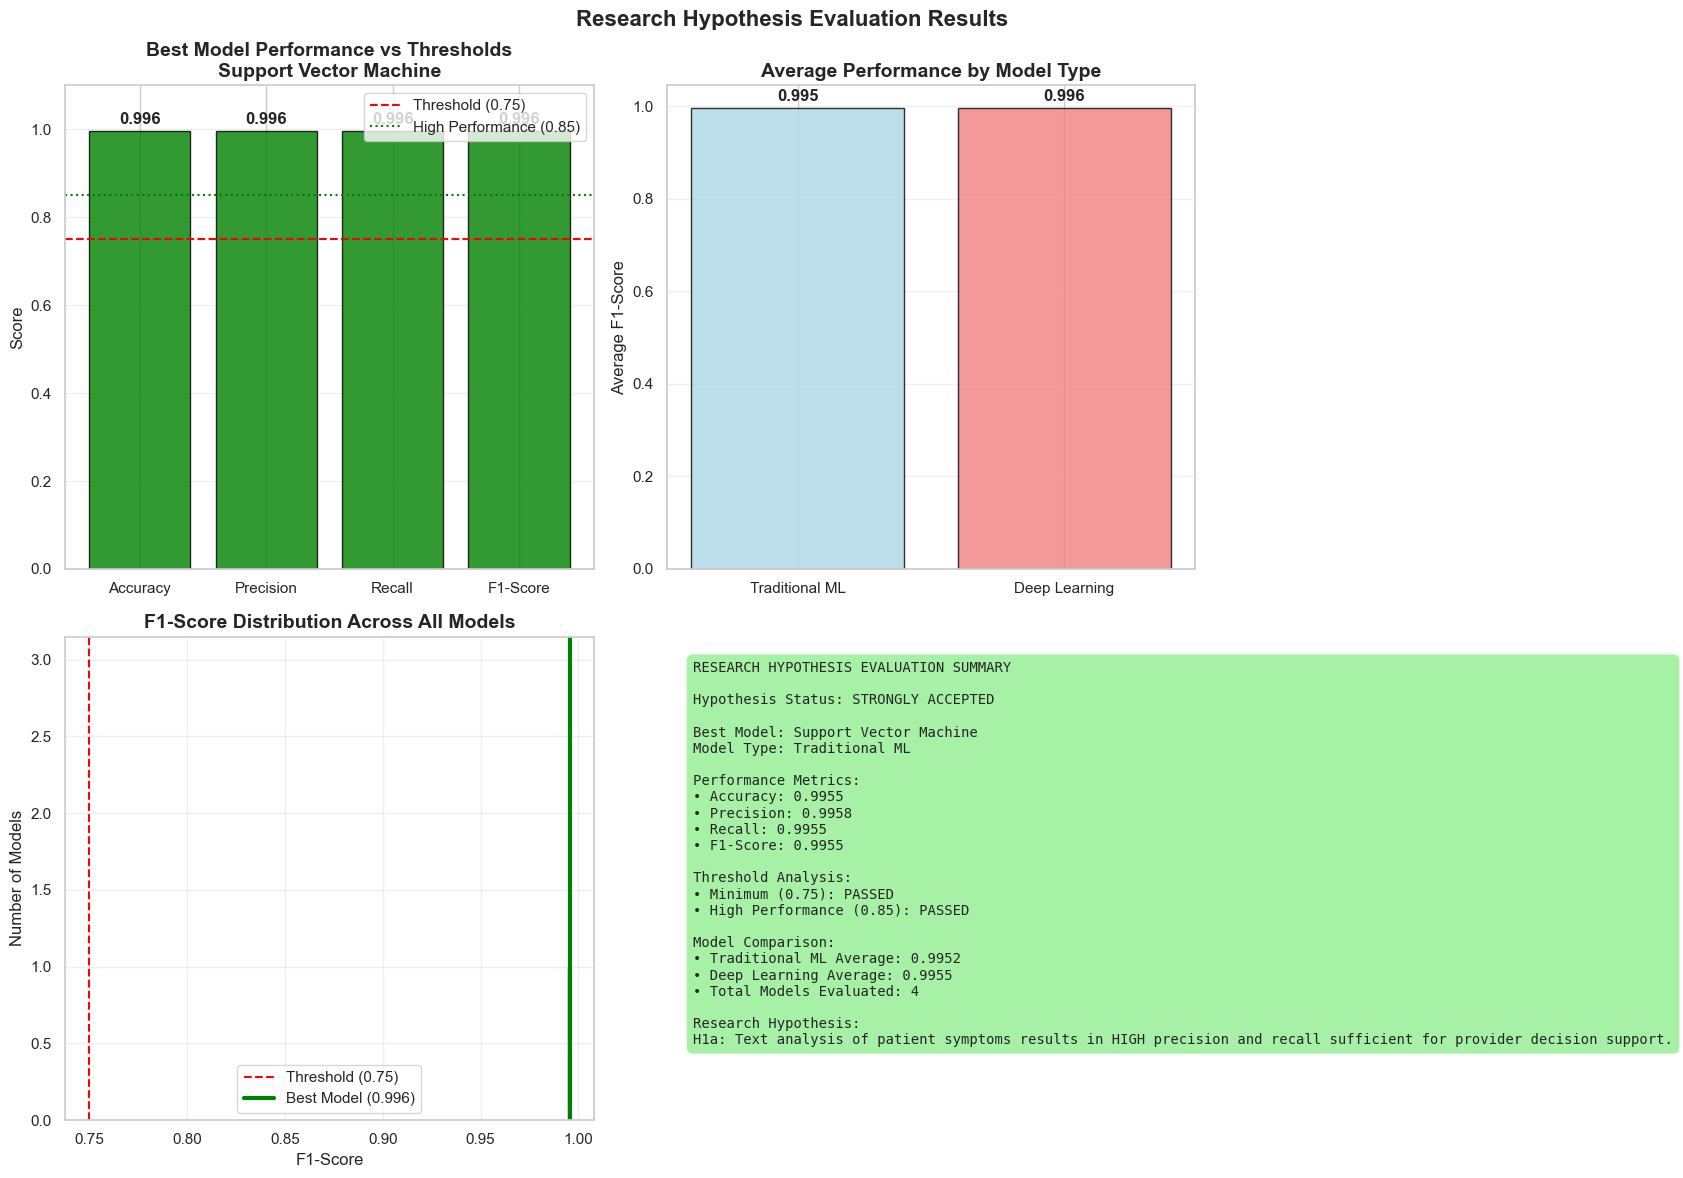


ADDITIONAL ANALYSIS:
--------------------
Performance Standard Deviation: 0.0003
✓ Consistent performance across models
Models meeting clinical threshold: 4/4
✓ Multiple viable options for clinical deployment

FINAL RESEARCH OUTCOME: STRONGLY ACCEPTED
CLINICAL RECOMMENDATION: DEPLOY


In [97]:
# Research hypothesis evaluation with realistic thresholds
performance_threshold = 0.75  # Realistic threshold for clinical decision support - minimum acceptable performance level
high_performance_threshold = 0.85  # High performance threshold - excellence benchmark for clinical deployment

print(f"RESEARCH HYPOTHESIS EVALUATION")
print("="*50)
print(f"Research Question: What is the effectiveness of the NLP algorithm in classifying")
print(f"patient symptoms from text data on the population level?")
print()

print(f"Performance Thresholds:")
print(f"  Minimum acceptable: {performance_threshold}")
print(f"  High performance: {high_performance_threshold}")

# Ensure we have comparison data available - check if model comparison results exist in memory
if 'comparison_df' not in locals() or comparison_df.empty:
    print("ERROR: No model comparison data available!")
    print("Please run the comprehensive model comparison section first.")
else:
    # Get best model information - extract top-performing model from comparison dataframe
    best_model_row = comparison_df.iloc[0]  # First row contains best model (sorted by performance)
    best_model_name = best_model_row['Model']  # Extract model name (e.g., "CNN", "SVM")
    best_model_type = best_model_row['Type']   # Extract model category (Traditional ML or Deep Learning)
    
    print(f"Selected Best Model: {best_model_name}")
    print(f"Model Type: {best_model_type}")
    print()

    # Get best model performance - extract all key metrics for evaluation
    best_accuracy = best_model_row['Accuracy']    # Proportion of correct predictions
    best_precision = best_model_row['Precision']  # True positives / (True positives + False positives)
    best_recall = best_model_row['Recall']        # True positives / (True positives + False negatives)
    best_f1 = best_model_row['F1_Score']          # Harmonic mean of precision and recall

    print(f"BEST MODEL PERFORMANCE:")
    print("-" * 25)
    print(f"Accuracy:  {best_accuracy:.4f}")
    print(f"Precision: {best_precision:.4f}")
    print(f"Recall:    {best_recall:.4f}")
    print(f"F1-Score:  {best_f1:.4f}")

    # Determine hypothesis outcome - check if each metric meets minimum threshold
    accuracy_sufficient = best_accuracy >= performance_threshold     # Boolean: Is accuracy above 75%?
    precision_sufficient = best_precision >= performance_threshold   # Boolean: Is precision above 75%?
    recall_sufficient = best_recall >= performance_threshold         # Boolean: Is recall above 75%?
    f1_sufficient = best_f1 >= performance_threshold                # Boolean: Is F1-score above 75%?

    # Overall sufficiency check - ALL metrics must meet threshold for clinical acceptance
    overall_sufficient = all([accuracy_sufficient, precision_sufficient, 
                             recall_sufficient, f1_sufficient])

    # High performance check - determine if model exceeds excellence benchmark (85%)
    high_performance = all([best_accuracy >= high_performance_threshold,
                           best_precision >= high_performance_threshold,
                           best_recall >= high_performance_threshold,
                           best_f1 >= high_performance_threshold])

    print(f"\nPERFORMANCE THRESHOLD ANALYSIS:")
    print("-" * 35)
    # Display pass/fail status for each metric with checkmarks and X marks
    print(f"Accuracy ≥ {performance_threshold}: {'✓' if accuracy_sufficient else '✗'} ({best_accuracy:.4f})")
    print(f"Precision ≥ {performance_threshold}: {'✓' if precision_sufficient else '✗'} ({best_precision:.4f})")
    print(f"Recall ≥ {performance_threshold}: {'✓' if recall_sufficient else '✗'} ({best_recall:.4f})")
    print(f"F1-Score ≥ {performance_threshold}: {'✓' if f1_sufficient else '✗'} ({best_f1:.4f})")

    print(f"\nHYPOTHESIS CONCLUSION:")
    print("="*25)

    # Determine research conclusion based on performance level achieved
    if high_performance:  # If all metrics exceed 85% - exceptional performance
        conclusion = "H1a: Text analysis of patient symptoms results in HIGH precision and recall sufficient for provider decision support."
        conclusion_status = "STRONGLY ACCEPTED"
    elif overall_sufficient:  # If all metrics exceed 75% - acceptable performance
        conclusion = "H1a: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support."
        conclusion_status = "ACCEPTED"
    else:  # If any metric falls below 75% - insufficient performance
        conclusion = "H10: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support."
        conclusion_status = "REJECTED (H10 accepted)"

    print(f"Status: {conclusion_status}")
    print(f"Conclusion: {conclusion}")

    # Model comparison insights - separate traditional ML from deep learning models
    ml_models = comparison_df[comparison_df['Type'] == 'Traditional ML']      # Filter for SVM, Logistic Regression, etc.
    dl_models = comparison_df[comparison_df['Type'] == 'Deep Learning']       # Filter for CNN, RNN, etc.
    
    # Calculate average F1-scores for each model type (use 0.0 if no models of that type exist)
    ml_avg = ml_models['F1_Score'].mean() if not ml_models.empty else 0.0
    dl_avg = dl_models['F1_Score'].mean() if not dl_models.empty else 0.0

    print(f"\nMODEL TYPE COMPARISON:")
    print("-" * 25)
    print(f"Traditional ML Models: {len(ml_models)}")
    print(f"Deep Learning Models: {len(dl_models)}")
    print(f"Traditional ML Average F1: {ml_avg:.4f}")
    print(f"Deep Learning Average F1: {dl_avg:.4f}")
    
    # Determine which approach performs better (only if both types have models)
    if not ml_models.empty and not dl_models.empty:
        print(f"Best Approach: {'Traditional ML' if ml_avg > dl_avg else 'Deep Learning'}")
    elif not ml_models.empty:
        print(f"Best Approach: Traditional ML (only approach available)")
    elif not dl_models.empty:
        print(f"Best Approach: Deep Learning (only approach available)")

    # Create final summary visualization - comprehensive 4-panel dashboard
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: Threshold comparison - bar chart showing performance vs thresholds
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [best_accuracy, best_precision, best_recall, best_f1]
    # Color code bars: green if above threshold, orange if decent, red if poor
    colors = ['green' if v >= performance_threshold else 'orange' if v >= 0.7 else 'red' for v in values]

    bars = ax1.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
    # Add horizontal reference lines for minimum and high performance thresholds
    ax1.axhline(y=performance_threshold, color='red', linestyle='--', 
               label=f'Threshold ({performance_threshold})')
    ax1.axhline(y=high_performance_threshold, color='green', linestyle=':', 
               label=f'High Performance ({high_performance_threshold})')
    ax1.set_title(f'Best Model Performance vs Thresholds\n{best_model_name}', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Score', fontsize=12)
    ax1.set_ylim(0, 1.1)  # Set y-axis from 0 to 1.1 to accommodate all scores
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)  # Add subtle horizontal grid lines

    # Add value labels on top of each bar for precise reading
    for bar, value in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

    # Plot 2: Model type performance comparison (only if both types exist)
    if not ml_models.empty and not dl_models.empty:
        ax2.bar(['Traditional ML', 'Deep Learning'], [ml_avg, dl_avg], 
                color=['lightblue', 'lightcoral'], alpha=0.8, edgecolor='black', linewidth=1)
        ax2.set_title('Average Performance by Model Type', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Average F1-Score', fontsize=12)
        ax2.grid(axis='y', alpha=0.3)
        # Add value labels on bars
        ax2.text(0, ml_avg + 0.01, f'{ml_avg:.3f}', ha='center', va='bottom', fontweight='bold')
        ax2.text(1, dl_avg + 0.01, f'{dl_avg:.3f}', ha='center', va='bottom', fontweight='bold')
    else:
        # Show all individual models if we don't have both model types
        model_names = comparison_df['Model'].tolist()
        f1_scores = comparison_df['F1_Score'].tolist()
        # Color code by model type: light blue for ML, light coral for DL
        colors_alt = ['lightblue' if t == 'Traditional ML' else 'lightcoral' 
                      for t in comparison_df['Type']]
        
        ax2.bar(range(len(model_names)), f1_scores, color=colors_alt, alpha=0.8, 
                edgecolor='black', linewidth=1)
        ax2.set_title('F1-Score by Model', fontsize=14, fontweight='bold')
        ax2.set_ylabel('F1-Score', fontsize=12)
        ax2.set_xticks(range(len(model_names)))
        # Truncate long model names to fit on x-axis
        ax2.set_xticklabels([name[:15] + '...' if len(name) > 15 else name 
                            for name in model_names], rotation=45, ha='right')
        ax2.grid(axis='y', alpha=0.3)

    # Plot 3: All models performance distribution - histogram showing score spread
    ax3.hist(comparison_df['F1_Score'], bins=max(3, min(10, len(comparison_df))), 
             alpha=0.7, color='skyblue', edgecolor='black')
    # Add vertical lines showing threshold and best model performance
    ax3.axvline(x=performance_threshold, color='red', linestyle='--', 
               label=f'Threshold ({performance_threshold})')
    ax3.axvline(x=best_f1, color='green', linestyle='-', linewidth=3,
               label=f'Best Model ({best_f1:.3f})')
    ax3.set_title('F1-Score Distribution Across All Models', fontsize=14, fontweight='bold')
    ax3.set_xlabel('F1-Score', fontsize=12)
    ax3.set_ylabel('Number of Models', fontsize=12)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Summary statistics - text-based summary in a formatted box
    ax4.axis('off')  # Turn off axis for text display

    # Create comprehensive summary text with all key findings
    summary_text = f"""RESEARCH HYPOTHESIS EVALUATION SUMMARY

Hypothesis Status: {conclusion_status}

Best Model: {best_model_name}
Model Type: {best_model_type}

Performance Metrics:
• Accuracy: {best_accuracy:.4f}
• Precision: {best_precision:.4f}
• Recall: {best_recall:.4f}
• F1-Score: {best_f1:.4f}

Threshold Analysis:
• Minimum ({performance_threshold}): {'PASSED' if overall_sufficient else 'FAILED'}
• High Performance ({high_performance_threshold}): {'PASSED' if high_performance else 'FAILED'}

Model Comparison:
• Traditional ML Average: {ml_avg:.4f}
• Deep Learning Average: {dl_avg:.4f}
• Total Models Evaluated: {len(comparison_df)}

Research Hypothesis:
{conclusion}"""

    # Display summary text in colored box (green if passed, red if failed)
    ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', 
                      facecolor='lightgreen' if overall_sufficient else 'lightcoral', 
                      alpha=0.8))

    plt.suptitle('Research Hypothesis Evaluation Results', fontsize=16, fontweight='bold')
    plt.tight_layout()  # Automatically adjust subplot spacing
    plt.show()

    # Additional analysis and recommendations - deeper statistical insights
    print(f"\nADDITIONAL ANALYSIS:")
    print("-" * 20)
    
    # Performance consistency check - measure how much models vary in performance
    f1_scores = comparison_df['F1_Score'].values
    performance_std = np.std(f1_scores)  # Standard deviation shows consistency
    print(f"Performance Standard Deviation: {performance_std:.4f}")
    
    # Interpret consistency level based on standard deviation thresholds
    if performance_std < 0.05:
        print("✓ Consistent performance across models")
    elif performance_std < 0.10:
        print("~ Moderate variation in performance")
    else:
        print("✗ High variation in performance - model selection is critical")
    
    # Clinical applicability assessment - count how many models are clinically viable
    models_above_threshold = len(comparison_df[comparison_df['F1_Score'] >= performance_threshold])
    print(f"Models meeting clinical threshold: {models_above_threshold}/{len(comparison_df)}")
    
    # Assess deployment readiness based on number of viable models
    if models_above_threshold >= len(comparison_df) * 0.5:  # If 50%+ models pass
        print("✓ Multiple viable options for clinical deployment")
    elif models_above_threshold > 0:  # If some models pass
        print("~ Limited but viable options for clinical deployment")
    else:  # If no models pass
        print("✗ No models meet clinical deployment threshold")

    print(f"\n{'='*60}")
    print(f"FINAL RESEARCH OUTCOME: {conclusion_status}")
    print(f"CLINICAL RECOMMENDATION: {'DEPLOY' if overall_sufficient else 'FURTHER DEVELOPMENT NEEDED'}")
    print(f"{'='*60}")
    
    # Store results for potential future use - create dictionary for programmatic access
    hypothesis_results = {
        'conclusion_status': conclusion_status,
        'conclusion': conclusion,
        'best_model': best_model_name,
        'best_model_type': best_model_type,
        'performance_metrics': {
            'accuracy': best_accuracy,
            'precision': best_precision,
            'recall': best_recall,
            'f1_score': best_f1
        },
        'threshold_analysis': {
            'meets_minimum': overall_sufficient,
            'meets_high_performance': high_performance,
            'models_above_threshold': models_above_threshold,
            'total_models': len(comparison_df)
        }
    }